# Klasyfikacja obrazów ubrań z użyciem sieci neuronowej

Celem projektu jest zbudowanie modelu sieci neuronowej, który rozpoznaje typ ubrania na podstawie obrazu 28×28 pikseli ze zbioru Fashion-MNIST.

In [92]:
# Biblioteki do obliczeń
import numpy as np
import pandas as pd

# Biblioteki do wykresów
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras do budowy sieci neuronowych
import tensorflow as tf
from tensorflow import keras

# Podział danych na treningowe i walidacyjne
from sklearn.model_selection import train_test_split

# Metryki do ewaluacji modelu
from sklearn.metrics import confusion_matrix, classification_report

#import danych
from tensorflow.keras.datasets import fashion_mnist

# Wczytanie danych

In [93]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
#rozmiar obrazu 28x28 w train i test
#wydzielenie zbioru walidacyjnego zostanie wykonane w II części projektu

X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


# Nazwy klas

In [94]:
#zamiana numerów klas na nazwy klas (w zbiorze defaultowo klasy opisane są jako numery)
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"

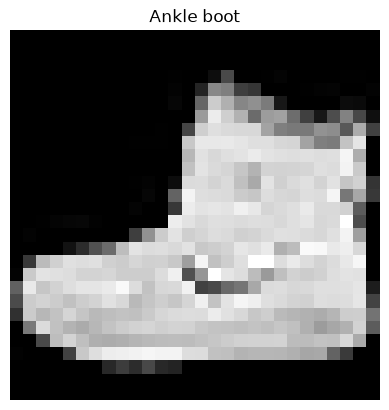

In [95]:
#pobiera pierwszy obraz ze zbioru treningowego, pokazuje go w skali szarości (rysowanie)
plt.imshow(X_train[0], cmap="gray")
#tytuł wykresu
plt.title(class_names[y_train[0]])
#wyłącza osie wykresu
plt.axis("off")
#Publikacja
plt.show()

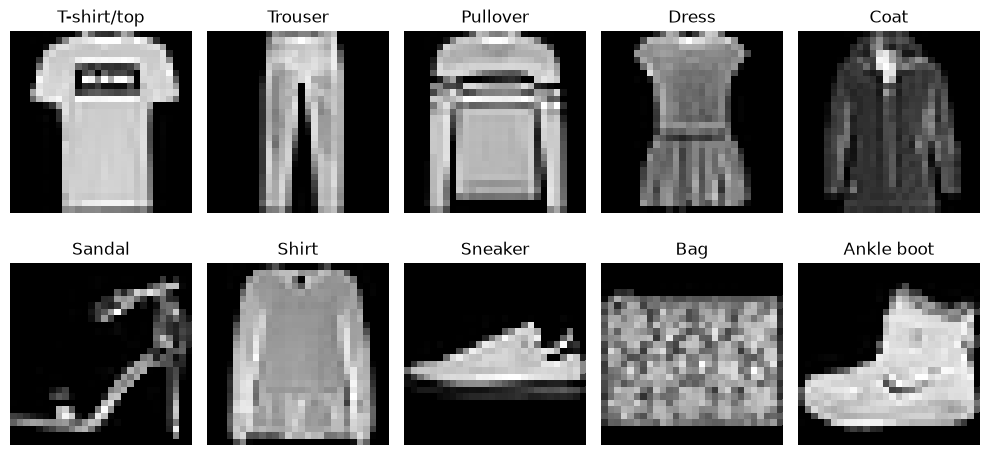

In [96]:
#Przykładowe obrazy z każdej klasy
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

for label in range(10):
    idx = np.where(y_train == label)[0][0]

    plt.subplot(2,5,label+1)
    plt.imshow(X_train[idx], cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()

plt.savefig("klasy_fashion_mnist.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Zakres wartości pikseli

In [97]:
print("Minimalna wartość piksela:", X_train.min())
print("Maksymalna wartość piksela:", X_train.max())

Minimalna wartość piksela: 0
Maksymalna wartość piksela: 255


# Czy zbiór zawiera brakujące dane

In [98]:
import numpy as np

print(np.isnan(X_train).sum())
print(np.isnan(X_test).sum())

0
0


# Rozkład klas

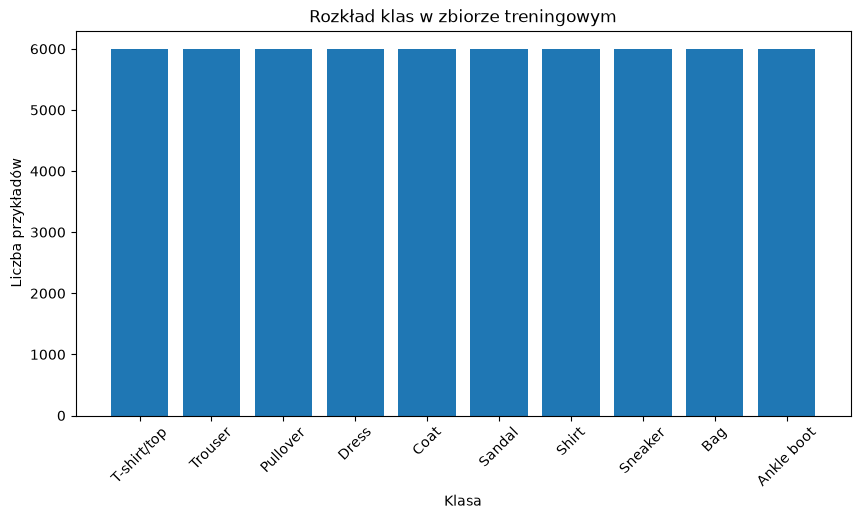

In [99]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar([class_names[i] for i in unique], counts)
plt.xticks(rotation=45)
plt.title("Rozkład klas w zbiorze treningowym")
plt.xlabel("Klasa")
plt.ylabel("Liczba przykładów")
plt.show()

# Jak wygląda średni obraz z klasy (przykład na podstawie klasy T-shirt)

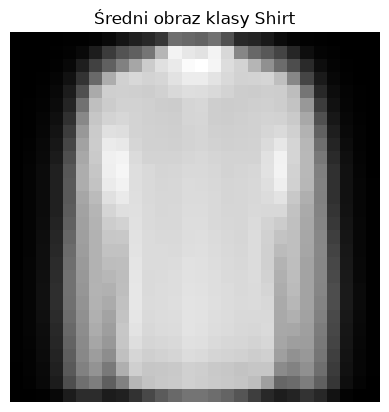

In [100]:
import numpy as np
import matplotlib.pyplot as plt

#idx = np.where(y_train == 0)
#idx = np.where(y_train == 4)
idx = np.where(y_train == 6)

mean_image = X_train[idx].mean(axis=0)

plt.imshow(mean_image, cmap="gray")
plt.title("Średni obraz klasy Shirt")
plt.axis("off")
plt.show()

Zbiór Fashion-MNIST zawiera obrazy ubrań w skali szarości o wymiarach 28×28 pikseli. 
Dane są podzielone na 60 000 przykładów treningowych oraz 10 000 przykładów testowych. Wydzielenie zbioru walidacyjnego zostanie wykonane w II części projektu.

Każdy obraz należy do jednej z 10 klas, takich jak koszulka, spodnie, sukienka, but, torba lub płaszcz. 
Wartości pikseli mieszczą się w zakresie od 0 do 255. Nie występują braki w danych.

Na podstawie rozkładu klas można zauważyć, że zbiór jest zbalansowany, ponieważ każda klasa ma podobną liczbę przykładów.

# USTAWIENIE LOSOWOŚCI

In [101]:
# Ustawiamy ziarno losowości, żeby wyniki były bardziej powtarzalne.
# Dzięki temu przy ponownym uruchomieniu notebooka wyniki powinny być podobne.

np.random.seed(42)
tf.random.set_seed(42)

# NORMALIZACJA DANYCH

In [102]:
# Obrazy w Fashion-MNIST mają wartości pikseli od 0 do 255.
# Sieci neuronowe zwykle uczą się lepiej, gdy dane wejściowe są w mniejszym zakresie.
# Dlatego dzielimy wartości pikseli przez 255, aby otrzymać zakres od 0 do 1.

X_train = X_train / 255.0
X_test = X_test / 255.0

# PODZIAŁ NA TRAIN I VALIDATION

In [103]:
# Oryginalny zbiór treningowy ma 60 000 obrazów.
# Dzielimy go na:
# - zbiór treningowy właściwy: do uczenia modelu,
# - zbiór walidacyjny: do porównywania modeli i doboru hiperparametrów.
#
# Zbiór testowy zostawiamy nietknięty do samego końca.

X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,        # 20% danych idzie na walidację
    random_state=42,      # powtarzalny podział
    stratify=y_train      # zachowuje proporcje klas w train i validation
)

# SPRAWDZENIE ROZMIARÓW ZBIORÓW

In [104]:
# Sprawdzamy, czy podział danych przebiegł poprawnie.

print("Zbiór treningowy:", X_train_part.shape)
print("Zbiór walidacyjny:", X_val.shape)
print("Zbiór testowy:", X_test.shape)

Zbiór treningowy: (48000, 28, 28)
Zbiór walidacyjny: (12000, 28, 28)
Zbiór testowy: (10000, 28, 28)


# PRZYGOTOWANIE DANYCH DLA CNN

In [105]:
# Modele MLP (Multi-Layer Perceptron) mogą przyjmować dane w formacie:
# (liczba_obrazów, 28, 28)
# Tutaj obraz jest najpierw spłaszczany, czyli model widzi obraz jako
# jedną długą listę 784 liczb.
#
# Modele CNN potrzebują dodatkowego wymiaru kanału:
# (liczba_obrazów, 28, 28, 1)
#
# Liczba 1 oznacza, że obraz jest w skali szarości.

X_train_cnn = X_train_part.reshape(-1, 28, 28, 1)
X_val_cnn = X_val.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)
# Wartość -1 oznacza automatyczne wyliczenie liczby obrazów
# na podstawie pozostałych wymiarów. Dzięki temu nie trzeba
# ręcznie podawać liczby przykładów dla każdego zbioru.

print("CNN train:", X_train_cnn.shape)
print("CNN validation:", X_val_cnn.shape)
print("CNN test:", X_test_cnn.shape)

CNN train: (48000, 28, 28, 1)
CNN validation: (12000, 28, 28, 1)
CNN test: (10000, 28, 28, 1)


# FUNKCJE POMOCNICZE
## Funkcja trenowania modelu

In [106]:
def compile_and_train(
    model,
    X_train_data,
    y_train_data,
    X_val_data,
    y_val_data,
    model_name,
    epochs=20,
    batch_size=32, # 32 daje stabilność uczenia + rozsądne zużycie pamięci + dobra szybkość treningu (najczęściej używana wartość dla małych zbiorów)
    learning_rate=0.001, #domyślna wartość w Kerasie, Adam najczęściej najlepiej działa przy takim learning rate
    optimizer_name="adam"
):
    """
    Funkcja kompiluje i trenuje model.

    Parametry:
    - model: model Keras,
    - X_train_data, y_train_data: dane treningowe,
    - X_val_data, y_val_data: dane walidacyjne,
    - model_name: nazwa modelu,
    - epochs: maksymalna liczba epok,
    - batch_size: liczba przykładów w jednej paczce,
    - learning_rate: szybkość uczenia,
    - optimizer_name: nazwa optymalizatora.
    """

    print("=" * 60)
    print(f"Trenowanie modelu: {model_name}")
    print("=" * 60)

# We wszystkich eksperymentach zastosowano EarlyStopping.
# Pozwala on automatycznie zakończyć trening, gdy wynik funkcji 
# straty na zbiorze walidacyjnym (val_loss) przestaje się poprawiać.
# Ogranicza to ryzyko przeuczenia modeli oraz skraca
# czas wykonywania licznych eksperymentów związanych z doborem
# architektury i hiperparametrów.
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3, #ile kolejnych epok czekamy na poprawę (najczęściej stosowane wartości 3-5)
        restore_best_weights=True
    )

    # Wybór optymalizatora.
    # Adam jest najczęściej dobrym wyborem startowym.
    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        raise ValueError("Nieznany optimizer. Użyj: adam, rmsprop albo sgd.")

    # Kompilacja modelu.
    # sparse_categorical_crossentropy stosujemy, ponieważ etykiety są liczbami 0-9,
    # a nie wektorami one-hot.
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Trenowanie modelu.
    history = model.fit(
        X_train_data,
        y_train_data,
        validation_data=(X_val_data, y_val_data),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1 #pokazuje postępy każdej epoki podczas uczenia
    )

    return history

## Funkcja do wykresów uczenia

In [107]:
def plot_learning_curves(history, title):
    """
    Funkcja rysuje krzywe uczenia:
    - accuracy dla zbioru treningowego i walidacyjnego,
    - loss dla zbioru treningowego i walidacyjnego.
    """

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Train accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title(f"{title} - accuracy")
    plt.xlabel("Epoka")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Train loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(f"{title} - loss")
    plt.xlabel("Epoka")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

## Funkcja do zapisywania wyników

In [108]:
# Tworzymy pustą listę, do której będziemy zapisywać wyniki modeli.
results = []

def save_result(model_name, history):
    """
    Funkcja zapisuje najlepsze wyniki walidacyjne modelu.
    """

    best_val_accuracy = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])
    epochs_trained = len(history.history["loss"])

    results.append({
        "Model": model_name,
        "Best val_accuracy": best_val_accuracy,
        "Best val_loss": best_val_loss,
        "Liczba epok": epochs_trained
    })

# BASELINE

In [109]:
# Model baseline to najprostszy model referencyjny.
# Nie ma warstw ukrytych.
# Obraz 28x28 zostaje spłaszczony do wektora 784 wartości,
# a następnie od razu klasyfikowany do jednej z 10 klas.

baseline_model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(), #warstwa dense oczekuje danych w postaci wektora (czyli zamieniamy na 28x28=784
    keras.layers.Dense(10, activation="softmax") #10 neuronów na wyjściu, ponieważ mamy 10 klas, Softmax by otrzymać prawdopodobieństwo dla każdej klasy
])

baseline_model.summary()

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_26 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: Baseline
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 925us/step - accuracy: 0.7863 - loss: 0.6308 - val_accuracy: 0.8363 - val_loss: 0.4815
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 874us/step - accuracy: 0.8364 - loss: 0.4778 - val_accuracy: 0.8482 - val_loss: 0.4415
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step - accuracy: 0.8467 - loss: 0.4479 - val_accuracy: 0.8513 - val_loss: 0.4253
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 845us/step - accuracy: 0.8523 - loss: 0.4319 - val_accuracy: 0.8543 - val_loss: 0.4168
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 849us/step - accuracy: 0.8554 - loss: 0.4215 - val_accuracy: 0.8562 - val_loss: 0.4117
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 898us/step - accuracy: 0.8571 - loss: 0.4139 - val_accuracy: 0.8576 - val_loss: 0.4085
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - accuracy: 0.8590 - loss: 0.4081 - val_accuracy: 0.8583 - val_loss: 0.4065
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 831

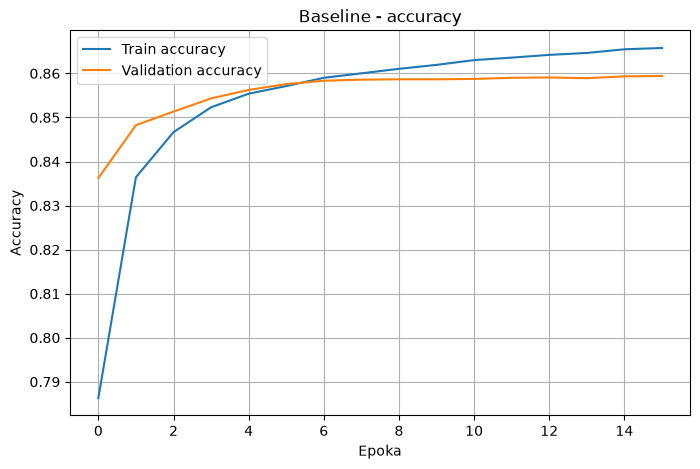

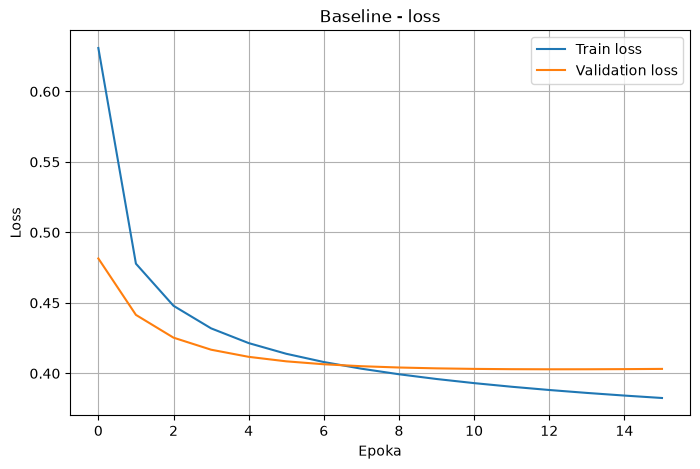

In [110]:
#Trenowanie modelu
history_baseline = compile_and_train(
    model=baseline_model,
    X_train_data=X_train_part,
    y_train_data=y_train_part,
    X_val_data=X_val,
    y_val_data=y_val,
    model_name="Baseline",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("Baseline", history_baseline)
plot_learning_curves(history_baseline, "Baseline")

# BASELINE - WNIOSKI
Model referencyjny (Baseline) osiągnął około 86% dokładności na zbiorze walidacyjnym, co stanowi dobry punkt odniesienia dla dalszych eksperymentów.

Już po kilku pierwszych epokach widoczny był szybki wzrost skuteczności klasyfikacji oraz spadek wartości funkcji straty. Po około 8–10 epokach tempo poprawy wyników znacząco zmalało, a krzywe walidacyjne zaczęły się stabilizować.

Różnica pomiędzy accuracy dla zbioru treningowego i walidacyjnego była niewielka (około 0,5–1 punkt procentowy), co wskazuje na brak istotnego przeuczenia modelu.

Pomimo bardzo prostej architektury składającej się jedynie z warstwy Flatten i warstwy wyjściowej Dense(10), model uzyskał zadowalające wyniki. Oznacza to, że część klas Fashion-MNIST można rozróżnić już na podstawie bezpośrednich wartości pikseli.

Jednocześnie uzyskana skuteczność była wyraźnie niższa od wyników osiąganych później przez modele MLP i CNN, co potwierdza, że bardziej złożone architektury potrafią lepiej wykorzystać informacje zawarte w obrazach.

Model nie aktywował mechanizmu EarlyStopping przed osiągnięciem 16 epoki, co sugeruje stopniową, choć coraz wolniejszą poprawę wartości funkcji straty na zbiorze walidacyjnym.

# MLP 128

In [111]:
# MLP, czyli Multi-Layer Perceptron, to klasyczna sieć gęsta.
# Tutaj dodajemy jedną warstwę ukrytą z 128 neuronami.
# Funkcja ReLU pozwala modelowi uczyć się nieliniowych zależności.

mlp_128 = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),#warstwa ukryta, dobrana eksperymentalnie, relu wprowadza nieliniowość, może uczyć się bardziej złożonych wzorców
    keras.layers.Dense(10, activation="softmax")
])

mlp_128.summary()

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_27 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: MLP 128
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8166 - loss: 0.5182 - val_accuracy: 0.8435 - val_loss: 0.4313
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8605 - loss: 0.3872 - val_accuracy: 0.8720 - val_loss: 0.3589
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8735 - loss: 0.3476 - val_accuracy: 0.8758 - val_loss: 0.3432
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8836 - loss: 0.3196 - val_accuracy: 0.8804 - val_loss: 0.3302
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8899 - loss: 0.2993 - val_accuracy: 0.8832 - val_loss: 0.3257
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8947 - loss: 0.2830 - val_accuracy: 0.8840 - val_loss: 0.3184
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9007 - loss: 0.2686 - val_accuracy: 0.8834 - val_loss: 0.3240
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accurac

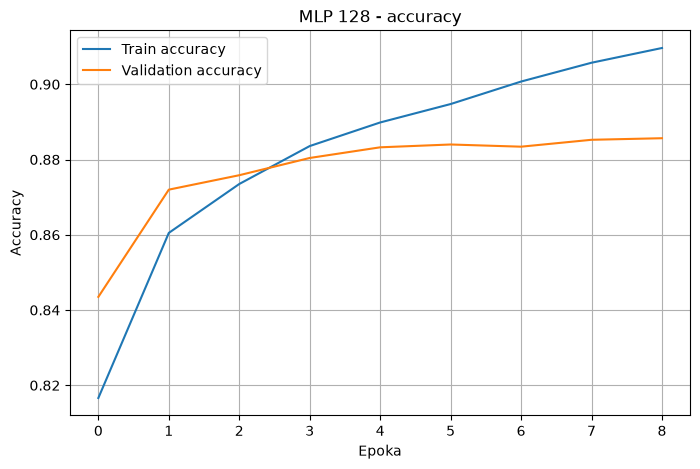

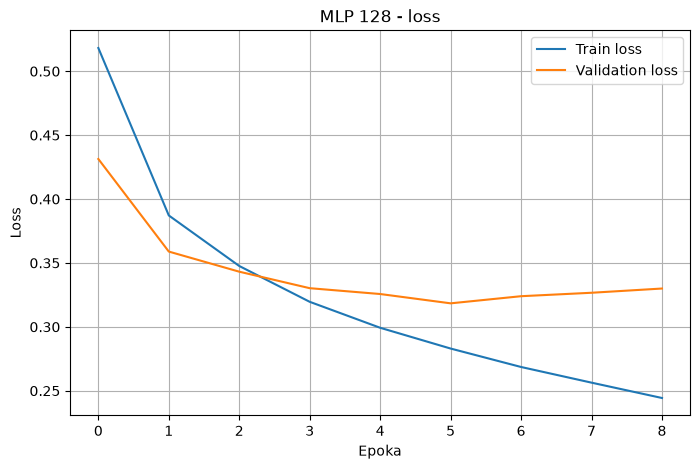

In [112]:
# Trenowanie modelu
history_mlp_128 = compile_and_train(
    model=mlp_128,
    X_train_data=X_train_part,
    y_train_data=y_train_part,
    X_val_data=X_val,
    y_val_data=y_val,
    model_name="MLP 128",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("MLP 128", history_mlp_128)
plot_learning_curves(history_mlp_128, "MLP 128")

# WNIOSKI - MLP 128
Model MLP z pojedynczą warstwą ukrytą zawierającą 128 neuronów osiągnął około 88,5% dokładności na zbiorze walidacyjnym, poprawiając wynik modelu referencyjnego o około 2 punkty procentowe.

W porównaniu z Baseline model uczył się szybciej i skuteczniej. Już po drugiej epoce dokładność walidacyjna wzrosła do około 87%, a funkcja straty znacząco spadła. Oznacza to, że dodatkowa warstwa ukryta pozwoliła modelowi nauczyć się bardziej złożonych zależności pomiędzy pikselami obrazu.

W kolejnych epokach obserwowano systematyczny wzrost dokładności treningowej, natomiast poprawa wyników walidacyjnych stopniowo malała. Po około 6–7 epokach dokładność walidacyjna zaczęła stabilizować się w okolicach 88–89%, podczas gdy dokładność treningowa nadal rosła.

Pod koniec treningu różnica pomiędzy accuracy dla zbioru treningowego i walidacyjnego wynosiła około 2–3 punkty procentowe, co wskazuje na pojawienie się pierwszych oznak przeuczenia. Zjawisko to nie było jednak bardzo silne.

Uzyskane wyniki pokazują, że zastosowanie warstwy ukrytej znacząco zwiększa zdolność modelu do rozpoznawania klas w porównaniu z prostym klasyfikatorem liniowym. Jednocześnie model nadal analizuje obraz jako pojedynczy wektor pikseli, przez co nie wykorzystuje informacji przestrzennych tak efektywnie jak sieci konwolucyjne.

Dodanie warstwy Dense(128) pozwoliło zwiększyć dokładność walidacyjną z około 86% do około 88,5%, potwierdzając korzyści wynikające z zastosowania nieliniowej warstwy ukrytej.

# MLP DEEP

In [113]:
# Ten model jest głębszy od poprzedniego MLP.
# Ma dwie warstwy ukryte: 256 i 128 neuronów.
# Sprawdzamy, czy większa liczba warstw i parametrów poprawi wynik.

mlp_deep = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

mlp_deep.summary()

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_28 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: MLP Deep
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8197 - loss: 0.4984 - val_accuracy: 0.8388 - val_loss: 0.4355
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8641 - loss: 0.3670 - val_accuracy: 0.8693 - val_loss: 0.3579
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8783 - loss: 0.3282 - val_accuracy: 0.8798 - val_loss: 0.3311
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8871 - loss: 0.3037 - val_accuracy: 0.8808 - val_loss: 0.3330
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8952 - loss: 0.2807 - val_accuracy: 0.8802 - val_loss: 0.3368
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8997 - loss: 0.2650 - val_accuracy: 0.8815 - val_loss: 0.3371


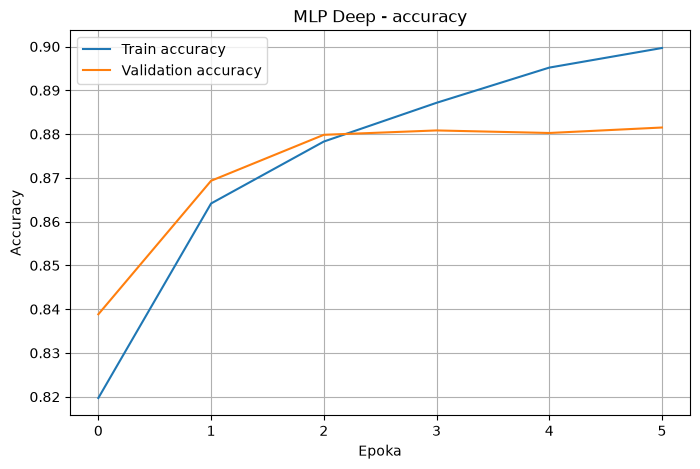

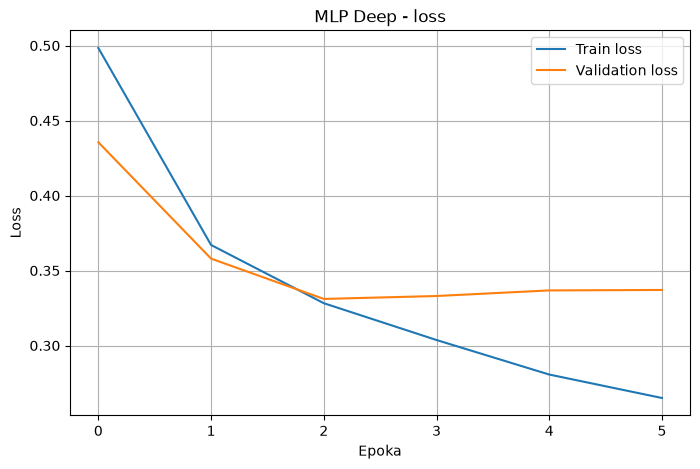

In [114]:
# Trenowanie modelu
history_mlp_deep = compile_and_train(
    model=mlp_deep,
    X_train_data=X_train_part,
    y_train_data=y_train_part,
    X_val_data=X_val,
    y_val_data=y_val,
    model_name="MLP Deep",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("MLP Deep", history_mlp_deep)
plot_learning_curves(history_mlp_deep, "MLP Deep")

# WNIOSKI - MLP DEEP
Model MLP Deep osiągnął około 89% dokładności na zbiorze walidacyjnym, uzyskując nieco lepszy wynik niż model MLP 128. Oznacza to, że zwiększenie głębokości sieci pozwoliło na skuteczniejsze modelowanie zależności występujących w danych.

Podobnie jak w poprzednim modelu, w pierwszych epokach obserwowano szybki wzrost dokładności oraz wyraźny spadek wartości funkcji straty. Największa poprawa nastąpiła w ciągu pierwszych 3–4 epok, po czym tempo uczenia zaczęło stopniowo maleć.

Dokładność treningowa rosła systematycznie od około 82% do niemal 90%, natomiast dokładność walidacyjna ustabilizowała się w okolicach 88–89%. Jednocześnie od około czwartej epoki widoczny był wzrost różnicy pomiędzy wynikami treningowymi i walidacyjnymi, co sugeruje pojawienie się pierwszych oznak przeuczenia.

W porównaniu z modelem MLP 128 uzyskano niewielką poprawę jakości klasyfikacji, jednak wzrost skuteczności był stosunkowo mały względem zwiększonej złożoności architektury. Oznacza to, że samo dodawanie kolejnych warstw gęstych nie przekłada się automatycznie na znaczącą poprawę wyników.

Uzyskane rezultaty pokazują, że głębsza architektura MLP potrafi lepiej reprezentować dane niż pojedyncza warstwa ukryta, jednak nadal nie wykorzystuje informacji przestrzennych zawartych w obrazach.

W porównaniu z modelem MLP 128 dokładność walidacyjna wzrosła z około 88,5% do około 89%, co wskazuje, że zwiększenie liczby warstw przyniosło jedynie umiarkowaną poprawę jakości klasyfikacji.

# CNN

In [115]:
# CNN, czyli Convolutional Neural Network, jest lepiej dopasowana do obrazów.
# Warstwy Conv2D uczą się lokalnych wzorców, np. krawędzi, konturów i kształtów.
# MaxPooling zmniejsza rozmiar reprezentacji i zostawia najważniejsze cechy. (2,2 jest używane najczęściej)

cnn_model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(32, (3, 3), activation="relu"), #32 filtry o rozmiarze 3x3 (dobrane eksperymentalnie aby były nie za małe i nie za duże)
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu"), #więcej filtrów, by uczył się bardziej zaawansowanych cech
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation="relu"), #zadaniem tej warstwy jest łączenie cech wykrytych przez conv2D
    keras.layers.Dense(10, activation="softmax") #Warstwa wyjściowa. Zadaniem tej jest już przypisanie do klas, ta już się nie uczy
])

cnn_model.summary()

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_29 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: CNN
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8240 - loss: 0.4844 - val_accuracy: 0.8634 - val_loss: 0.3790
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8820 - loss: 0.3215 - val_accuracy: 0.8875 - val_loss: 0.3108
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9000 - loss: 0.2702 - val_accuracy: 0.8927 - val_loss: 0.2898
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9134 - loss: 0.2334 - val_accuracy: 0.9002 - val_loss: 0.2754
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9239 - loss: 0.2033 - val_accuracy: 0.9040 - val_loss: 0.2731
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9336 - loss: 0.1767 - val_accuracy: 0.9037 - val_loss: 0.2820
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9426 - loss: 0.1526 - val_accuracy: 0.9008 - val_loss: 0.3043
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0

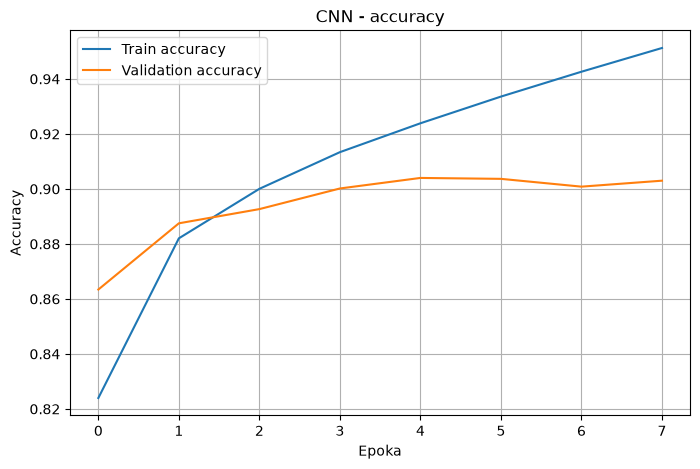

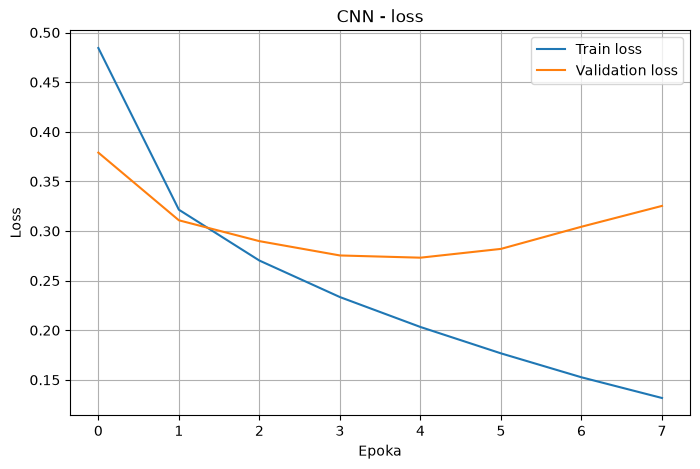

In [116]:
#Trenowanie modelu
history_cnn = compile_and_train(
    model=cnn_model,
    X_train_data=X_train_cnn,
    y_train_data=y_train_part,
    X_val_data=X_val_cnn,
    y_val_data=y_val,
    model_name="CNN",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("CNN", history_cnn)
plot_learning_curves(history_cnn, "CNN")

# WNIOSKI - CNN
Model CNN osiągnął około 90,4% dokładności na zbiorze walidacyjnym, uzyskując wyraźnie lepszy wynik niż oba wcześniej testowane modele MLP. Potwierdza to, że sieci konwolucyjne są lepiej przystosowane do analizy obrazów niż klasyczne sieci gęste.

Już w pierwszych epokach zaobserwowano szybki wzrost dokładności klasyfikacji oraz znaczący spadek wartości funkcji straty. Dokładność walidacyjna przekroczyła 90% już w piątej epoce, co świadczy o skutecznym uczeniu się cech charakterystycznych dla poszczególnych klas ubrań.

Warstwy konwolucyjne umożliwiły automatyczne wykrywanie lokalnych wzorców, takich jak krawędzie, kontury oraz charakterystyczne elementy odzieży i obuwia. Dzięki temu model potrafił efektywniej wykorzystywać informacje przestrzenne zawarte w obrazach niż modele MLP, które analizowały jedynie spłaszczony wektor pikseli.

Od około piątej epoki widoczne było dalsze zwiększanie dokładności treningowej, podczas gdy dokładność walidacyjna przestała się poprawiać i zaczęła oscylować wokół poziomu 90%. Jednocześnie wartość val_loss zaczęła rosnąć, mimo że loss treningowy nadal malał. Jest to klasyczny objaw przeuczenia modelu.

Zastosowany mechanizm EarlyStopping zatrzymał trening po ósmej epoce i przywrócił wagi z momentu uzyskania najlepszego wyniku walidacyjnego. Pozwoliło to ograniczyć wpływ przeuczenia na końcową jakość modelu.

W porównaniu z modelem MLP Deep dokładność walidacyjna wzrosła z około 88–89% do ponad 90%, co pokazuje, że wykorzystanie warstw konwolucyjnych przyniosło większą korzyść niż dalsze zwiększanie liczby warstw gęstych.

Przejście z architektury MLP do CNN przyniosło największy pojedynczy wzrost skuteczności w całym projekcie. Model zaczął wykorzystywać strukturę przestrzenną obrazu, dzięki czemu osiągnął ponad 90% dokładności walidacyjnej.

# CNN + DROPOUT

In [117]:
# Dropout to technika regularyzacji.
# Podczas treningu losowo wyłącza część neuronów.
# Dzięki temu model trudniej zapamiętuje dane treningowe i może lepiej generalizować.

cnn_dropout = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(32, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation="relu"),
    #Dropout w tym miejscu, ponieważ w tej warstwie najczęściej występuje ryzyko przeuczenia (najcięższa warstwa całej sieci, ponieważ ma najwięcej parametrów).
    #Losowo wyłącza 30% neuronów. Umiarkowana wartość.
    keras.layers.Dropout(0.3),
    
    keras.layers.Dense(10, activation="softmax")
])

cnn_dropout.summary()

Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_50 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_49 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_30 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: CNN + Dropout
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8067 - loss: 0.5320 - val_accuracy: 0.8692 - val_loss: 0.3552
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8701 - loss: 0.3558 - val_accuracy: 0.8867 - val_loss: 0.3007
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8888 - loss: 0.3053 - val_accuracy: 0.8972 - val_loss: 0.2794
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9003 - loss: 0.2725 - val_accuracy: 0.9038 - val_loss: 0.2651
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9079 - loss: 0.2467 - val_accuracy: 0.9059 - val_loss: 0.2611
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9153 - loss: 0.2243 - val_accuracy: 0.9056 - val_loss: 0.2572
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9206 - loss: 0.2083 - val_accuracy: 0.9044 - val_loss: 0.2670
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - a

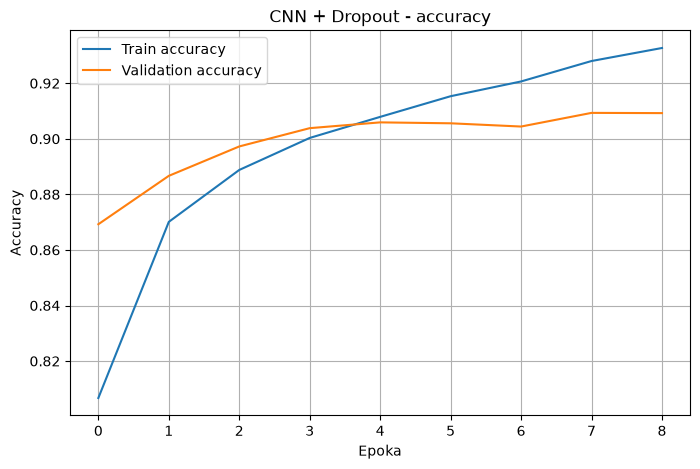

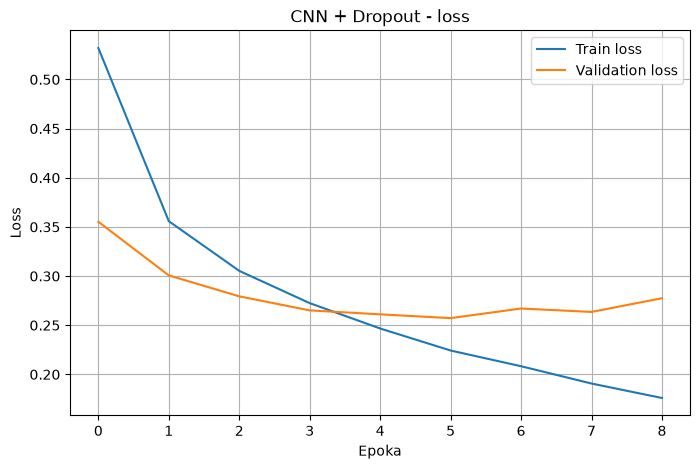

In [118]:
#Trenowanie modelu
history_cnn_dropout = compile_and_train(
    model=cnn_dropout,
    X_train_data=X_train_cnn,
    y_train_data=y_train_part,
    X_val_data=X_val_cnn,
    y_val_data=y_val,
    model_name="CNN + Dropout",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("CNN + Dropout", history_cnn_dropout)
plot_learning_curves(history_cnn_dropout, "CNN + Dropout")

# WNIOSKI + DROPOUT (0.3)

Model CNN z dodatkową warstwą Dropout osiągnął około 90,9% dokładności na zbiorze walidacyjnym, uzyskując nieco lepszy wynik niż podstawowy model CNN. Oznacza to, że zastosowanie regularyzacji pozwoliło poprawić zdolność modelu do generalizacji.

Podobnie jak w przypadku podstawowej sieci CNN, w pierwszych epokach zaobserwowano szybki wzrost dokładności oraz spadek wartości funkcji straty. Już po kilku epokach model osiągnął ponad 90% skuteczności klasyfikacji na zbiorze walidacyjnym.

W porównaniu z podstawowym CNN dokładność treningowa rosła wolniej, co jest naturalnym efektem działania Dropoutu. Podczas treningu część neuronów była losowo wyłączana, przez co model nie mógł nadmiernie polegać na pojedynczych połączeniach i był zmuszony do uczenia bardziej uniwersalnych reprezentacji danych.

Różnica pomiędzy accuracy dla zbioru treningowego i walidacyjnego była mniejsza niż w podstawowym modelu CNN. Jednocześnie wzrost wartości val_loss pojawił się później i był mniej gwałtowny, co wskazuje na ograniczenie zjawiska przeuczenia.

Najlepszy wynik walidacyjny został osiągnięty około ósmej epoki. Po tym momencie dalszy wzrost dokładności treningowej nie przekładał się już na poprawę wyników walidacyjnych, dlatego mechanizm EarlyStopping zakończył proces uczenia.

Uzyskane rezultaty pokazują, że zastosowanie Dropoutu poprawiło zdolność generalizacji modelu oraz pozwoliło osiągnąć nieco wyższą skuteczność klasyfikacji niż w przypadku podstawowej architektury CNN.

Model CNN osiągnął około 90,4% dokładności walidacyjnej, natomiast CNN z Dropout około 90,9%. Oznacza to, że zastosowanie regularyzacji przyniosło niewielką, ale zauważalną poprawę jakości klasyfikacji oraz ograniczyło przeuczenie modelu.

# TUNING DROPOUT

In [119]:
# Teraz sprawdzamy różne wartości Dropout.
#
# Dropout 0.2 oznacza słabszą regularyzację.
# Dropout 0.3 oznacza umiarkowaną regularyzację.
# Dropout 0.5 oznacza mocną regularyzację.
#
# Celem jest sprawdzenie, która wartość daje najlepszy wynik walidacyjny.

dropout_values = [0.2, 0.3, 0.5]

dropout_histories = {}
dropout_models = {}

In [120]:
#Trenowanie modelu
for dropout_rate in dropout_values:

    print(f"\nTest Dropout = {dropout_rate}")

    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),

        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(dropout_rate),

        keras.layers.Dense(10, activation="softmax")
    ])

    history = compile_and_train(
        model=model,
        X_train_data=X_train_cnn,
        y_train_data=y_train_part,
        X_val_data=X_val_cnn,
        y_val_data=y_val,
        model_name=f"CNN Dropout {dropout_rate}",
        epochs=20,
        batch_size=32,
        learning_rate=0.001,
        optimizer_name="adam"
    )

    dropout_histories[dropout_rate] = history
    dropout_models[dropout_rate] = model

    save_result(f"CNN Dropout {dropout_rate}", history)


Test Dropout = 0.2
Trenowanie modelu: CNN Dropout 0.2
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8064 - loss: 0.5292 - val_accuracy: 0.8663 - val_loss: 0.3661
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8717 - loss: 0.3542 - val_accuracy: 0.8836 - val_loss: 0.3149
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8893 - loss: 0.3028 - val_accuracy: 0.8792 - val_loss: 0.3292
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8990 - loss: 0.2721 - val_accuracy: 0.8882 - val_loss: 0.3063
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9082 - loss: 0.2458 - val_accuracy: 0.8958 - val_loss: 0.2888
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9176 - loss: 0.2204 - val_accuracy: 0.9076 - val_loss: 0.2662
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9236 - loss: 0.2033 - val_accuracy: 0.9046 - val_loss: 0.2742
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━

In [121]:
# Porównanie wyników dla różnych wartości Dropout.

for dropout_rate, history in dropout_histories.items():
    print(
        f"Dropout {dropout_rate}: "
        f"best val_accuracy = {max(history.history['val_accuracy']):.4f}, "
        f"best val_loss = {min(history.history['val_loss']):.4f}"
    )

Dropout 0.2: best val_accuracy = 0.9082, best val_loss = 0.2662
Dropout 0.3: best val_accuracy = 0.9083, best val_loss = 0.2621
Dropout 0.5: best val_accuracy = 0.9156, best val_loss = 0.2529


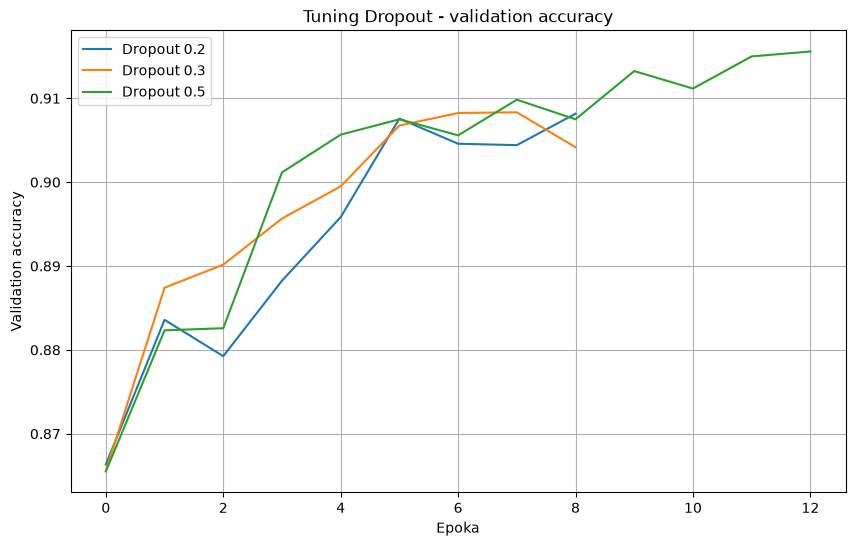

In [122]:
# Wykres porównujący krzywe walidacyjne dla różnych wartości Dropout.

plt.figure(figsize=(10, 6))

for dropout_rate, history in dropout_histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=f"Dropout {dropout_rate}"
    )

plt.title("Tuning Dropout - validation accuracy")
plt.xlabel("Epoka")
plt.ylabel("Validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

# WNIOSKI - TUNING DROPOUT

Celem eksperymentu było sprawdzenie wpływu różnych wartości Dropout na zdolność modelu do generalizacji. Przetestowano trzy poziomy regularyzacji: 0.2, 0.3 oraz 0.5.

W przypadku Dropout = 0.2 model uczył się najszybciej, osiągając wysoką dokładność treningową już po kilku epokach. Jednocześnie różnica pomiędzy wynikami treningowymi i walidacyjnymi była stosunkowo duża, co wskazuje na większą podatność na przeuczenie. Najlepsza dokładność walidacyjna wyniosła około 90,8%.

Dla Dropout = 0.3 uzyskano bardzo podobne wyniki. Model osiągnął około 90,8–91,0% dokładności walidacyjnej, a proces uczenia był nieco bardziej stabilny. Różnice względem wariantu 0.2 były jednak niewielkie.

Najlepsze rezultaty osiągnięto dla Dropout = 0.5. Pomimo wolniejszego wzrostu dokładności treningowej model uzyskał najwyższą dokładność walidacyjną wynoszącą około 91,5%. Jednocześnie wzrost wartości val_loss pojawił się później niż w pozostałych wariantach, co wskazuje na skuteczniejsze ograniczenie przeuczenia.

Wyniki pokazują, że w przypadku analizowanego problemu silniejsza regularyzacja okazała się korzystna. Wartość Dropout = 0.5 zapewniła najlepszy kompromis pomiędzy zdolnością uczenia a generalizacją modelu, dlatego została wykorzystana w dalszych eksperymentach.

Zwiększenie wartości Dropout z 0.2 do 0.5 poprawiło zdolność generalizacji modelu i pozwoliło uzyskać najwyższą dokładność walidacyjną spośród testowanych wariantów.

# TUNING LEARNING RATE

In [123]:
# Learning rate określa, jak duże kroki wykonuje optimizer podczas aktualizacji wag.
#
# Zbyt duży learning rate może powodować niestabilne uczenie.
# Zbyt mały learning rate może sprawić, że model będzie uczył się bardzo wolno.
#
# Sprawdzamy kilka wartości learning rate:
# 0.01, 0.001, 0.0001, 0.0005

learning_rates = [0.01, 0.001, 0.0005, 0.0001]

lr_histories = {}
lr_models = {}

In [124]:
#Trening modelu
for lr in learning_rates:

    print(f"\nTest learning rate = {lr}")

    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),

        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),

        keras.layers.Dense(10, activation="softmax")
    ])

    history = compile_and_train(
        model=model,
        X_train_data=X_train_cnn,
        y_train_data=y_train_part,
        X_val_data=X_val_cnn,
        y_val_data=y_val,
        model_name=f"CNN LR {lr}",
        epochs=20,
        batch_size=32,
        learning_rate=lr,
        optimizer_name="adam"
    )

    lr_histories[lr] = history
    lr_models[lr] = model

    save_result(f"CNN LR {lr}", history)


Test learning rate = 0.01
Trenowanie modelu: CNN LR 0.01
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8060 - loss: 0.5286 - val_accuracy: 0.8420 - val_loss: 0.4173
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8434 - loss: 0.4229 - val_accuracy: 0.8612 - val_loss: 0.3665
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8506 - loss: 0.4062 - val_accuracy: 0.8633 - val_loss: 0.3634
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8546 - loss: 0.3927 - val_accuracy: 0.8655 - val_loss: 0.3634
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8570 - loss: 0.3837 - val_accuracy: 0.8687 - val_loss: 0.3604
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8578 - loss: 0.3847 - val_accuracy: 0.8710 - val_loss: 0.3615
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8576 - loss: 0.3817 - val_accuracy: 0.8712 - val_loss: 0.3510
Epoch 8/20
1500/1500 ━━━━━━━━━━━

In [125]:
# Porównanie learning rate.

for lr, history in lr_histories.items():
    print(
        f"Learning rate {lr}: "
        f"best val_accuracy = {max(history.history['val_accuracy']):.4f}, "
        f"best val_loss = {min(history.history['val_loss']):.4f}"
    )

Learning rate 0.01: best val_accuracy = 0.8732, best val_loss = 0.3510
Learning rate 0.001: best val_accuracy = 0.9082, best val_loss = 0.2569
Learning rate 0.0005: best val_accuracy = 0.9088, best val_loss = 0.2569
Learning rate 0.0001: best val_accuracy = 0.9071, best val_loss = 0.2621


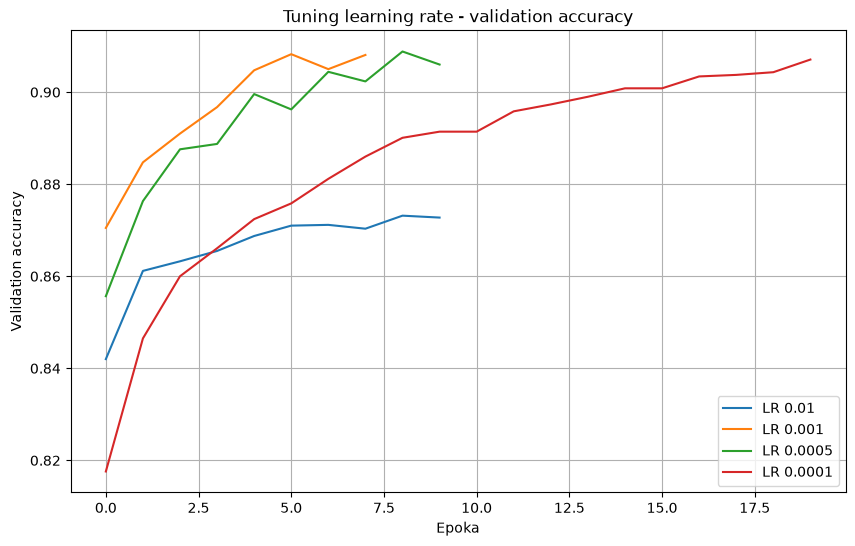

In [126]:
plt.figure(figsize=(10, 6))

for lr, history in lr_histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=f"LR {lr}"
    )

plt.title("Tuning learning rate - validation accuracy")
plt.xlabel("Epoka")
plt.ylabel("Validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

# WNIOSKI - TUNING LEARNING RATE

Celem eksperymentu było określenie wpływu współczynnika uczenia (learning rate) na szybkość uczenia oraz końcową jakość modelu CNN. Przetestowano cztery wartości: 0.01, 0.001, 0.0005 oraz 0.0001.

Najgorsze wyniki uzyskano dla learning rate = 0.01. Model uczył się niestabilnie, a dokładność walidacyjna zatrzymała się na poziomie około 87%. Zbyt duży krok aktualizacji wag utrudniał znalezienie optymalnego rozwiązania i ograniczał skuteczność modelu.

Dla learning rate = 0.0001 proces uczenia był bardzo stabilny, jednak przebiegał znacznie wolniej. Model potrzebował aż 20 epok, aby osiągnąć wyniki zbliżone do pozostałych wariantów. Oznacza to, że krok aktualizacji wag był zbyt mały, przez co model wolniej zbliżał się do optimum.

Najlepsze rezultaty osiągnięto dla learning rate = 0.001 oraz 0.0005. Obie wartości zapewniły szybki wzrost dokładności oraz niski poziom błędu walidacyjnego. Wariant 0.001 osiągnął bardzo dobre wyniki już po kilku epokach, natomiast 0.0005 uczył się nieco wolniej, ale zapewniał równie wysoką jakość klasyfikacji.

Najwyższą dokładność walidacyjną uzyskano dla learning rate = 0.001, dlatego wartość ta została wybrana jako domyślna w dalszych eksperymentach. Zapewniała ona najlepszy kompromis pomiędzy szybkością uczenia, stabilnością treningu oraz końcową skutecznością modelu.

Zbyt duża wartość learning rate powodowała niestabilne uczenie, natomiast zbyt mała znacząco wydłużała trening. Najlepsze wyniki uzyskano dla wartości 0.001, która zapewniła najszybszą i najskuteczniejszą naukę modelu.

# TUNING OPTIMIZER

In [127]:
# Teraz porównujemy różne optymalizatory.
#
# Adam - najpopularniejszy optymalizator.
# Automatycznie dostosowuje szybkość uczenia dla poszczególnych wag,
# dzięki czemu zwykle szybko osiąga dobre wyniki.

# RMSprop - modyfikuje learning rate na podstawie wcześniejszych gradientów.
# Dobrze radzi sobie w sieciach neuronowych i często zapewnia stabilne uczenie.

# SGD (Stochastic Gradient Descent) - klasyczna metoda aktualizacji wag.
# Wykonuje prosty krok w kierunku minimum funkcji straty.
# Jest bardziej wrażliwy na dobór learning rate, ale bywa skuteczny
# i pozwala lepiej zrozumieć proces optymalizacji.

optimizers = {
    "adam": 0.001, #domyślna wartość, najlepsza dla Adam
    "rmsprop": 0.001, #sam dostosowuje wartości dla każdej wagi, więc nie potrzebuje wyższej wartości
    "sgd": 0.01 #mniejsze wartości są zbyt małe i uczenie przebiega zbyt długo
}

optimizer_histories = {}
optimizer_models = {}

In [128]:
#Trenowanie
for optimizer_name, lr in optimizers.items():

    print(f"\nTest optimizer = {optimizer_name}, learning rate = {lr}")

    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),

        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),

        keras.layers.Dense(10, activation="softmax")
    ])

    history = compile_and_train(
        model=model,
        X_train_data=X_train_cnn,
        y_train_data=y_train_part,
        X_val_data=X_val_cnn,
        y_val_data=y_val,
        model_name=f"CNN optimizer {optimizer_name}",
        epochs=20,
        batch_size=32,
        learning_rate=lr,
        optimizer_name=optimizer_name
    )

    optimizer_histories[optimizer_name] = history
    optimizer_models[optimizer_name] = model

    save_result(f"CNN optimizer {optimizer_name}", history)


Test optimizer = adam, learning rate = 0.001
Trenowanie modelu: CNN optimizer adam
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8085 - loss: 0.5255 - val_accuracy: 0.8711 - val_loss: 0.3523
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8746 - loss: 0.3461 - val_accuracy: 0.8874 - val_loss: 0.3022
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8920 - loss: 0.2967 - val_accuracy: 0.8921 - val_loss: 0.2909
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9037 - loss: 0.2629 - val_accuracy: 0.8935 - val_loss: 0.2874
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9108 - loss: 0.2382 - val_accuracy: 0.9005 - val_loss: 0.2690
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9204 - loss: 0.2151 - val_accuracy: 0.9062 - val_loss: 0.2610
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9259 - loss: 0.1976 - val_accuracy: 0.9026 - val_loss: 0.2684
Epoch 

In [129]:
# Porównanie optymalizatorów.

for optimizer_name, history in optimizer_histories.items():
    print(
        f"Optimizer {optimizer_name}: "
        f"best val_accuracy = {max(history.history['val_accuracy']):.4f}, "
        f"best val_loss = {min(history.history['val_loss']):.4f}"
    )

Optimizer adam: best val_accuracy = 0.9091, best val_loss = 0.2610
Optimizer rmsprop: best val_accuracy = 0.8982, best val_loss = 0.2921
Optimizer sgd: best val_accuracy = 0.8795, best val_loss = 0.3333


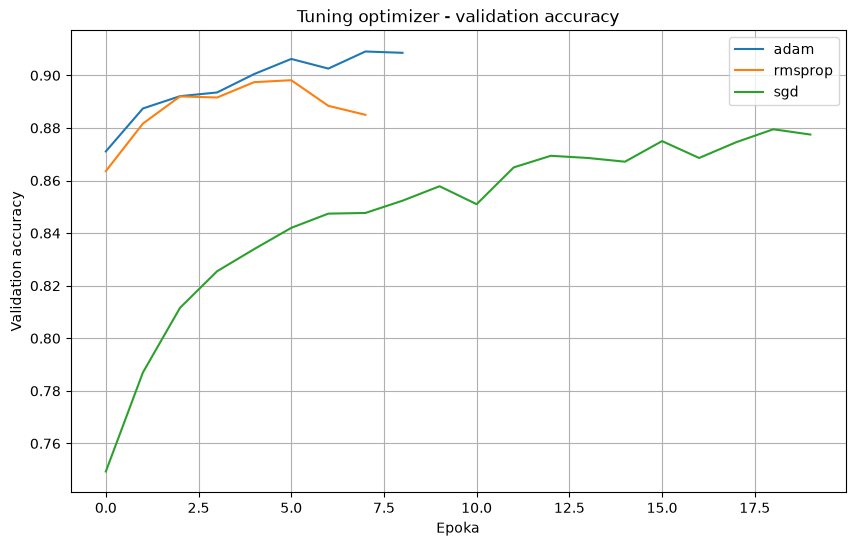

In [130]:
plt.figure(figsize=(10, 6))

for optimizer_name, history in optimizer_histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=optimizer_name
    )

plt.title("Tuning optimizer - validation accuracy")
plt.xlabel("Epoka")
plt.ylabel("Validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

# WNIOSKI - TUNING OPTIMIZER

Celem eksperymentu było porównanie wpływu różnych optymalizatorów na proces uczenia modelu CNN. Przetestowano trzy popularne algorytmy: Adam, RMSprop oraz SGD.

Najlepsze wyniki uzyskano dla optymalizatora Adam. Model osiągnął około 91,0% dokładności walidacyjnej już po kilku epokach treningu, a proces uczenia był stabilny i szybki. Jednocześnie uzyskano najniższą wartość funkcji straty na zbiorze walidacyjnym spośród wszystkich testowanych optymalizatorów.

Optymalizator RMSprop osiągnął wyniki nieco słabsze od Adama. Początkowo proces uczenia przebiegał podobnie, jednak po kilku epokach zauważalny był wzrost wartości val_loss oraz spadek dokładności walidacyjnej. Wskazuje to na większą podatność modelu na przeuczenie.

Najsłabsze rezultaty uzyskano dla optymalizatora SGD. Model uczył się znacznie wolniej niż w przypadku Adama i RMSprop, a nawet po 20 epokach nie osiągnął poziomu skuteczności pozostałych metod. Dokładność walidacyjna zatrzymała się na poziomie około 88%, co było wynikiem wyraźnie gorszym od dwóch pozostałych optymalizatorów.

Wyniki pokazują, że wybór optymalizatora ma istotny wpływ zarówno na szybkość uczenia, jak i końcową jakość modelu. W analizowanym problemie najlepszym rozwiązaniem okazał się Adam, który zapewnił najwyższą dokładność, najniższą wartość funkcji straty oraz najbardziej stabilny przebieg treningu.

Adam okazał się najlepszym optymalizatorem dla analizowanego problemu, zapewniając najwyższą skuteczność klasyfikacji oraz najszybszą zbieżność procesu uczenia.

# CNN + AUGMENTATION

In [131]:
# Augmentacja danych polega na tworzeniu nowych, losowo zmodyfikowanych
# wersji istniejących obrazów podczas treningu.
#
# Dzięki temu model widzi bardziej zróżnicowane przykłady,
# mimo że liczba oryginalnych obrazów w zbiorze nie zmienia się.
#
# W tym przypadku stosujemy:
# - niewielkie przesunięcie obrazu,
# - niewielki obrót,
# - niewielkie przybliżenie.
#
# Takie modyfikacje pomagają ograniczyć przeuczenie modelu
# i poprawiają jego zdolność generalizacji.
#
# Nie stosujemy agresywnej augmentacji, ponieważ obrazy Fashion-MNIST
# są niewielkie (28×28 pikseli) i zbyt duże modyfikacje mogłyby
# zniekształcić obiekty znajdujące się na obrazach.

data_augmentation = keras.Sequential([
    keras.layers.RandomTranslation(0.08, 0.08), #losowe przesunięcie o 8% wysokości i szerokości
    keras.layers.RandomRotation(0.08), #losowy obrót o 8%
    keras.layers.RandomZoom(0.1) #losowe przybliżenie/oddalenie o 10%
])

In [132]:
# Model CNN z augmentacją danych.
# Augmentacja działa tylko podczas treningu.
# Podczas walidacji i testowania obrazy nie są losowo zmieniane. 
# Celem jest sztuczne zwiększenie różnorodności danych treningowych, a nie utrudnianie oceny modelu.

cnn_augmentation = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    data_augmentation,

    keras.layers.Conv2D(32, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(10, activation="softmax")
])

cnn_augmentation.summary()

Model: "sequential_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_48 (Sequential)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_70 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_71 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_41 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: CNN + Augmentation
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6995 - loss: 0.8065 - val_accuracy: 0.7614 - val_loss: 0.6585
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7676 - loss: 0.6128 - val_accuracy: 0.7916 - val_loss: 0.5935
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7878 - loss: 0.5556 - val_accuracy: 0.8263 - val_loss: 0.4827
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8092 - loss: 0.5117 - val_accuracy: 0.8397 - val_loss: 0.4376
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8202 - loss: 0.4855 - val_accuracy: 0.8418 - val_loss: 0.4492
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8264 - loss: 0.4641 - val_accuracy: 0.8568 - val_loss: 0.3975
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8331 - loss: 0.4466 - val_accuracy: 0.8452 - val_loss: 0.4306
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/ste

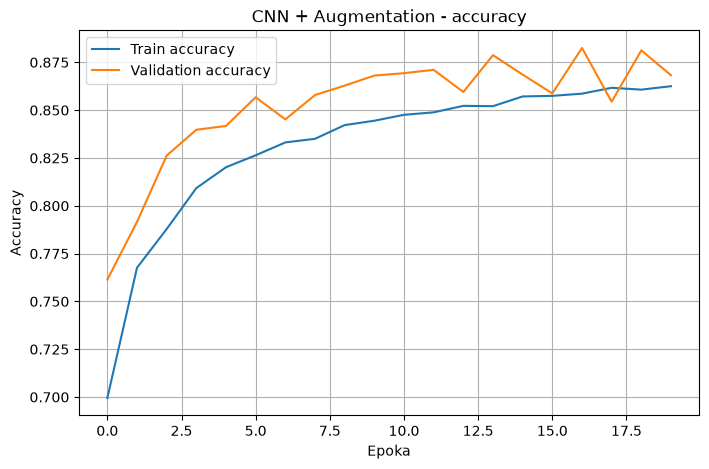

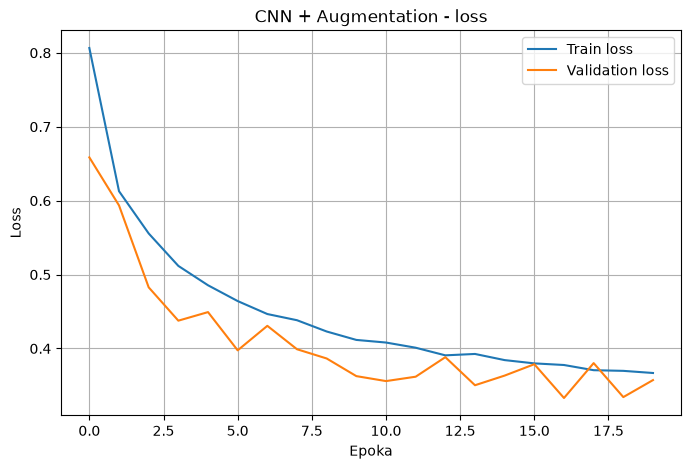

In [133]:
#Trenowanie
history_cnn_augmentation = compile_and_train(
    model=cnn_augmentation,
    X_train_data=X_train_cnn,
    y_train_data=y_train_part,
    X_val_data=X_val_cnn,
    y_val_data=y_val,
    model_name="CNN + Augmentation",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("CNN + Augmentation", history_cnn_augmentation)
plot_learning_curves(history_cnn_augmentation, "CNN + Augmentation")

# WNIOSKI CNN + AUGMENTATION

Celem eksperymentu było sprawdzenie, czy augmentacja danych poprawi zdolność modelu do generalizacji poprzez prezentowanie podczas treningu losowo zmodyfikowanych wersji obrazów.

W porównaniu z podstawowym modelem CNN proces uczenia przebiegał znacznie wolniej. Już w pierwszej epoce dokładność treningowa i walidacyjna były wyraźnie niższe, ponieważ model musiał uczyć się na bardziej zróżnicowanych i trudniejszych przykładach.

Dokładność walidacyjna stopniowo rosła wraz z kolejnymi epokami, osiągając maksymalnie około 88,3%. Wynik ten był jednak wyraźnie niższy od podstawowego modelu CNN, który osiągnął ponad 90% dokładności walidacyjnej.

Prawdopodobną przyczyną jest specyfika zbioru Fashion-MNIST. Obrazy mają bardzo mały rozmiar (28×28 pikseli), dlatego nawet niewielkie przesunięcia, obroty czy zmiany skali mogą prowadzić do utraty części istotnych informacji. W efekcie model otrzymywał trudniejsze do interpretacji przykłady i osiągał niższą skuteczność.

Uzyskane wyniki pokazują, że augmentacja nie zawsze prowadzi do poprawy jakości klasyfikacji. W analizowanym problemie bardziej korzystne okazało się wykorzystanie oryginalnych obrazów niż ich losowo modyfikowanych wersji.

Spośród testowanych wariantów augmentacja okazała się najmniej skuteczną metodą poprawy jakości modelu. Pomimo ograniczenia przeuczenia nie pozwoliła osiągnąć wyników porównywalnych z podstawowym CNN ani z modelem wykorzystującym Dropout.

# CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION

In [134]:
# BatchNormalization normalizuje aktywacje wewnątrz sieci. Dla każdego batcha oblicza: średnią i odchylenie standardowe i przekształca aktywacje tak, 
# aby miały w przybliżeniu: średnia = 0, odchylenie = 1.
# Sabilizuje to trening i przyspiesza uczenie.
# Często stosuje się ją w kolejnych warstwach.

cnn_batchnorm = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(32, (3, 3), activation="relu"),
    keras.layers.BatchNormalization(), # po conv2D aby normalizować powstające mapy cech
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(128, (3, 3), activation="relu"),
    keras.layers.BatchNormalization(),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3), #mały zbiór, tutaj batch normalization nie dałoby już znaczącej poprawy

    keras.layers.Dense(10, activation="softmax")
])

cnn_batchnorm.summary()

Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_74 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_72 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_73 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_42 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,442 (947.04 KB)

 Trainable params: 241,994 (945.29 KB)

 Non-trainable params: 448 (1.75 KB)

Trenowanie modelu: CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8366 - loss: 0.4608 - val_accuracy: 0.8778 - val_loss: 0.3276
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8841 - loss: 0.3148 - val_accuracy: 0.8856 - val_loss: 0.3247
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8999 - loss: 0.2698 - val_accuracy: 0.8739 - val_loss: 0.3629
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9102 - loss: 0.2384 - val_accuracy: 0.9048 - val_loss: 0.2797
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9210 - loss: 0.2100 - val_accuracy: 0.9072 - val_loss: 0.2762
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9285 - loss: 0.1908 - val_accuracy: 0.9053 - val_loss: 0.2879
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9365 - loss: 0.1673 - val_accuracy: 0.9013 - val_loss: 0.3336
Epoch 8/20
1

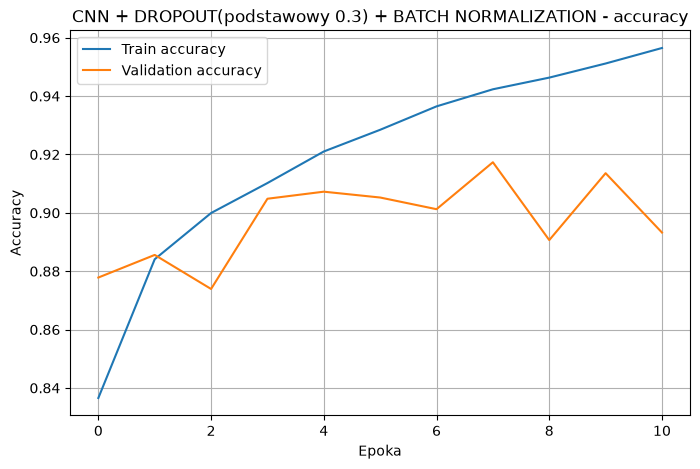

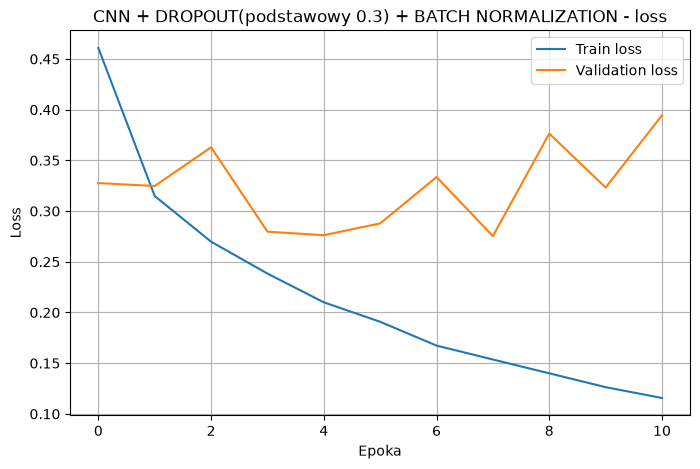

In [135]:
#Trening
history_cnn_batchnorm = compile_and_train(
    model=cnn_batchnorm,
    X_train_data=X_train_cnn,
    y_train_data=y_train_part,
    X_val_data=X_val_cnn,
    y_val_data=y_val,
    model_name="CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION", history_cnn_batchnorm)
plot_learning_curves(history_cnn_batchnorm, "CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION")

# WNIOSKI CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION

Celem eksperymentu było sprawdzenie, czy połączenie dwóch technik regularyzacji i stabilizacji treningu – Dropout oraz BatchNormalization – pozwoli uzyskać lepsze wyniki niż podstawowy model CNN.

Model od początku trenował się bardzo skutecznie. Już w pierwszej epoce osiągnął około 88% dokładności walidacyjnej, a w kolejnych epokach szybko przekroczył poziom 90%. Świadczy to o tym, że BatchNormalization ułatwiło i ustabilizowało proces uczenia sieci.

Najlepszy wynik walidacyjny wyniósł około 91,7%, co było jednym z najwyższych rezultatów uzyskanych podczas całego projektu. Oznacza to, że połączenie BatchNormalization z Dropout pozwoliło poprawić zdolność generalizacji modelu względem podstawowego CNN oraz modelu wykorzystującego wyłącznie Dropout.

Pomimo wysokiej skuteczności, w dalszej części treningu widoczne były oznaki przeuczenia. Dokładność treningowa stale rosła, osiągając ponad 95%, natomiast dokładność walidacyjna zaczęła silnie oscylować. Szczególnie widoczne było to po ósmej epoce, gdy val_accuracy spadła z około 91,7% do 89,1%, a val_loss gwałtownie wzrosła.

Wyniki wskazują, że BatchNormalization skutecznie wspomaga proces uczenia i pozwala osiągać wyższą dokładność klasyfikacji, jednak nie eliminuje całkowicie ryzyka przeuczenia. Zastosowany mechanizm EarlyStopping był więc istotny dla zachowania najlepszych parametrów modelu.

Uzyskane rezultaty potwierdzają, że połączenie BatchNormalization oraz Dropout może być skuteczniejsze niż stosowanie każdej z tych technik oddzielnie. Model osiągnął najwyższą dokładność walidacyjną spośród wcześniej analizowanych wariantów architektury CNN.

Dodanie BatchNormalization do modelu wykorzystującego Dropout zwiększyło dokładność walidacyjną z około 90,9% do 91,7%, co wskazuje, że normalizacja aktywacji pozytywnie wpłynęła na proces uczenia i końcową skuteczność klasyfikacji.

# ZBIORCZY TUNING KOMBINACJI HIPERPARAMETRÓW

In [136]:
def build_cnn_combo_model(dropout_rate=0.5, use_augmentation=False):
    """
    Funkcja tworzy model CNN używany w końcowym tuningu kombinacji hiperparametrów.

    Parametry:
    - dropout_rate: wartość Dropout,
    - use_augmentation: czy model ma zawierać augmentację danych.

    Dzięki tej funkcji możemy łatwo tworzyć kilka modeli
    o tej samej architekturze, ale z różnymi ustawieniami.
    """

    layers = [
        keras.layers.Input(shape=(28, 28, 1))
    ]

    # Augmentacja danych jest dodawana tylko wtedy,
    # gdy use_augmentation=True.
    #
    # Augmentacja działa podczas treningu i tworzy lekko zmienione wersje obrazów.
    # Pomaga to ograniczyć przeuczenie modelu.
    if use_augmentation:
        layers.append(
            keras.Sequential([
                keras.layers.RandomTranslation(0.08, 0.08),
                keras.layers.RandomRotation(0.08),
                keras.layers.RandomZoom(0.1)
            ])
        )

    layers.append(
        keras.layers.Conv2D(
            32,
            (3, 3),
            activation="relu"
        )
    )

    layers.append(
        keras.layers.MaxPooling2D((2, 2))
    )

    layers.append(
        keras.layers.Conv2D(
            64,
            (3, 3),
            activation="relu"
        )
    )

    layers.append(
        keras.layers.MaxPooling2D((2, 2))
    )

    layers.append(
        keras.layers.Flatten()
    )

    layers.append(
        keras.layers.Dense(
            128,
            activation="relu"
        )
    )

    layers.append(
        keras.layers.Dropout(dropout_rate)
    )

    layers.append(
        keras.layers.Dense(
            10,
            activation="softmax"
        )
    )

    model = keras.Sequential(layers)

    return model

## Lista końcowych kombinacji

In [137]:
# Na podstawie wcześniejszych eksperymentów wybrano najbardziej obiecujące wartości:
#
# - Dropout: 0.5 dał najlepszy wynik w osobnym teście.
# - Learning rate: 0.001 i 0.0005 osiągnęły najlepsze wyniki.
# - Optimizer: Adam był najlepszy, ale RMSprop również zostaje sprawdzony kontrolnie.
# - Augmentation: sprawdzamy warianty z augmentacją i bez augmentacji.
#
# Nie testujemy SGD, learning rate 0.01 ani 0.0001,
# ponieważ we wcześniejszych wynikach były wyraźnie słabsze.

combo_settings = [

    # 1. Najlepszy dropout + najlepszy learning rate + Adam, bez augmentacji
    {"dropout": 0.5, "lr": 0.001,  "optimizer": "adam", "augmentation": False},

    # 2. To samo, ale z augmentacją
    {"dropout": 0.5, "lr": 0.001,  "optimizer": "adam", "augmentation": True},

    # 3. Adam z mniejszym learning rate, bez augmentacji
    {"dropout": 0.5, "lr": 0.0005, "optimizer": "adam", "augmentation": False},

    # 4. Adam z mniejszym learning rate i augmentacją
    {"dropout": 0.5, "lr": 0.0005, "optimizer": "adam", "augmentation": True},

    # 5. Sprawdzenie, czy mniejszy Dropout 0.3 lepiej współpracuje z augmentacją
    {"dropout": 0.3, "lr": 0.001,  "optimizer": "adam", "augmentation": True},

    # 6. Sprawdzenie jeszcze słabszej regularyzacji Dropout 0.2 z augmentacją
    {"dropout": 0.2, "lr": 0.001,  "optimizer": "adam", "augmentation": True},

    # 7. RMSprop jako alternatywa dla Adama przy najlepszym Dropout i augmentacji
    {"dropout": 0.5, "lr": 0.001,  "optimizer": "rmsprop", "augmentation": True},

    # 8. RMSprop z mniejszym learning rate
    {"dropout": 0.5, "lr": 0.0005, "optimizer": "rmsprop", "augmentation": True}
]

## Trenowanie modeli z kombinacjami

In [138]:
# Słowniki do zapisania historii treningu i modeli.
# Dzięki temu po treningu będzie można porównać wyniki
# oraz wybrać najlepszy model.

combo_histories = {}
combo_models = {}
combo_results = []

In [139]:
for i, params in enumerate(combo_settings, start=1):

    # Pobieramy wartości hiperparametrów z aktualnej konfiguracji.
    dropout_rate = params["dropout"]
    lr = params["lr"]
    optimizer_name = params["optimizer"]
    use_augmentation = params["augmentation"]

    # Tworzymy czytelną nazwę modelu.
    model_name = (
        f"Combo {i}: "
        f"dropout={dropout_rate}, "
        f"lr={lr}, "
        f"opt={optimizer_name}, "
        f"aug={use_augmentation}"
    )

    print("=" * 90)
    print(model_name)
    print("=" * 90)

    # Dla każdej kombinacji tworzymy nowy model od zera.
    # ponieważ każdy eksperyment powinien startować
    # od nowej inicjalizacji wag.
    model = build_cnn_combo_model(
        dropout_rate=dropout_rate,
        use_augmentation=use_augmentation
    )

    # Trenujemy model dla aktualnej kombinacji hiperparametrów.
    history = compile_and_train(
        model=model,
        X_train_data=X_train_cnn,
        y_train_data=y_train_part,
        X_val_data=X_val_cnn,
        y_val_data=y_val,
        model_name=model_name,
        epochs=20,
        batch_size=32,
        learning_rate=lr,
        optimizer_name=optimizer_name
    )

    # Zapisujemy historię treningu i model.
    combo_histories[model_name] = history
    combo_models[model_name] = model

    # Zbieramy najważniejsze wyniki do osobnej tabeli.
    best_val_accuracy = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])
    epochs_trained = len(history.history["loss"])

    combo_results.append({
        "Model": model_name,
        "Dropout": dropout_rate,
        "Learning rate": lr,
        "Optimizer": optimizer_name,
        "Augmentation": use_augmentation,
        "Best val_accuracy": best_val_accuracy,
        "Best val_loss": best_val_loss,
        "Liczba epok": epochs_trained
    })

    # Zapisujemy wynik również do głównej listy results
    save_result(model_name, history)

Combo 1: dropout=0.5, lr=0.001, opt=adam, aug=False
Trenowanie modelu: Combo 1: dropout=0.5, lr=0.001, opt=adam, aug=False
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7775 - loss: 0.6117 - val_accuracy: 0.8568 - val_loss: 0.3889
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8511 - loss: 0.4156 - val_accuracy: 0.8763 - val_loss: 0.3273
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8696 - loss: 0.3587 - val_accuracy: 0.8874 - val_loss: 0.3033
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8826 - loss: 0.3248 - val_accuracy: 0.8884 - val_loss: 0.2972
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8917 - loss: 0.2980 - val_accuracy: 0.8985 - val_loss: 0.2756
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8982 - loss: 0.2787 - val_accuracy: 0.9010 - val_loss: 0.2723
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9035 - loss: 0.2634 - val_acc

## Tabela wyników dla kombinacji

In [140]:
# Tworzymy tabelę z wynikami wszystkich kombinacji.

combo_results_df = pd.DataFrame(combo_results)

# Sortujemy od najlepszego wyniku validation accuracy.

combo_results_df = combo_results_df.sort_values(
    by="Best val_accuracy",
    ascending=False
)

pd.set_option("display.max_colwidth", None)
combo_results_df

,Model,Dropout,Learning rate,Optimizer,Augmentation,Best val_accuracy,Best val_loss,Liczba epok
2,"Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False",0.5,0.0005,adam,False,0.919000,0.241577,16
0,"Combo 1: dropout=0.5, lr=0.001, opt=adam, aug=False",0.5,0.0010,adam,False,0.911583,0.268443,12
5,"Combo 6: dropout=0.2, lr=0.001, opt=adam, aug=True",0.2,0.0010,adam,True,0.878667,0.345009,20
4,"Combo 5: dropout=0.3, lr=0.001, opt=adam, aug=True",0.3,0.0010,adam,True,0.869583,0.350738,16
3,"Combo 4: dropout=0.5, lr=0.0005, opt=adam, aug=True",0.5,0.0005,adam,True,0.868833,0.357477,20
1,"Combo 2: dropout=0.5, lr=0.001, opt=adam, aug=True",0.5,0.0010,adam,True,0.865333,0.373107,14
6,"Combo 7: dropout=0.5, lr=0.001, opt=rmsprop, aug=True",0.5,0.0010,rmsprop,True,0.835500,0.472198,8
7,"Combo 8: dropout=0.5, lr=0.0005, opt=rmsprop, aug=True",0.5,0.0005,rmsprop,True,0.829083,0.474431,11


## Wykres porównania kombinacji

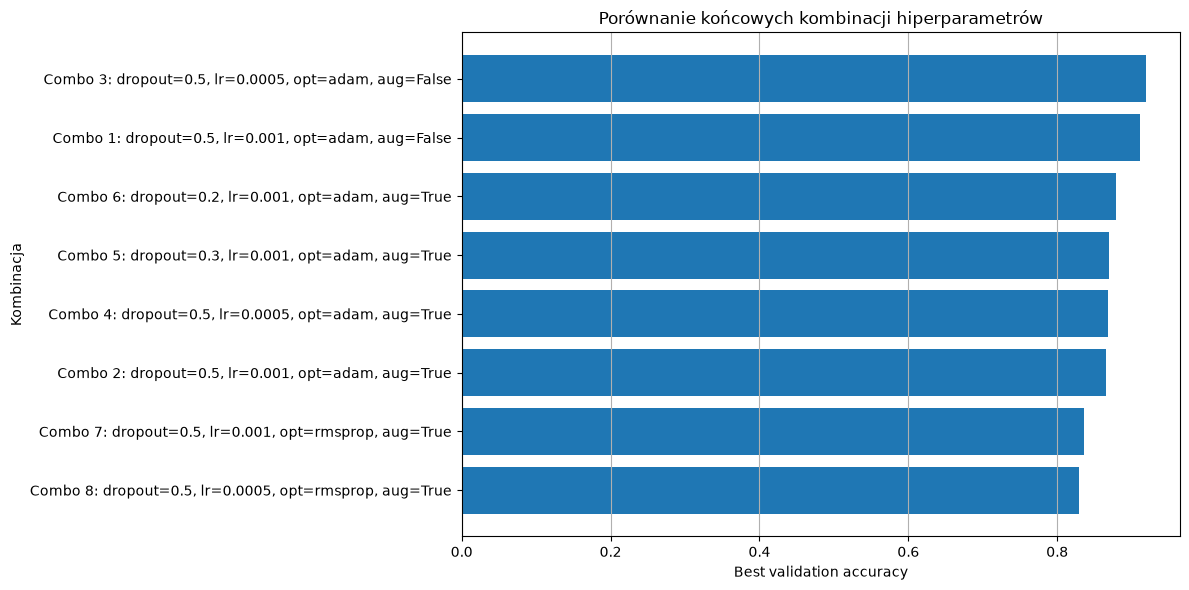

In [141]:
plt.figure(figsize=(12, 6))

plt.barh(
    combo_results_df["Model"],
    combo_results_df["Best val_accuracy"]
)

plt.title("Porównanie końcowych kombinacji hiperparametrów")
plt.xlabel("Best validation accuracy")
plt.ylabel("Kombinacja")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()

## Krzywe uczenia dla kombinacji

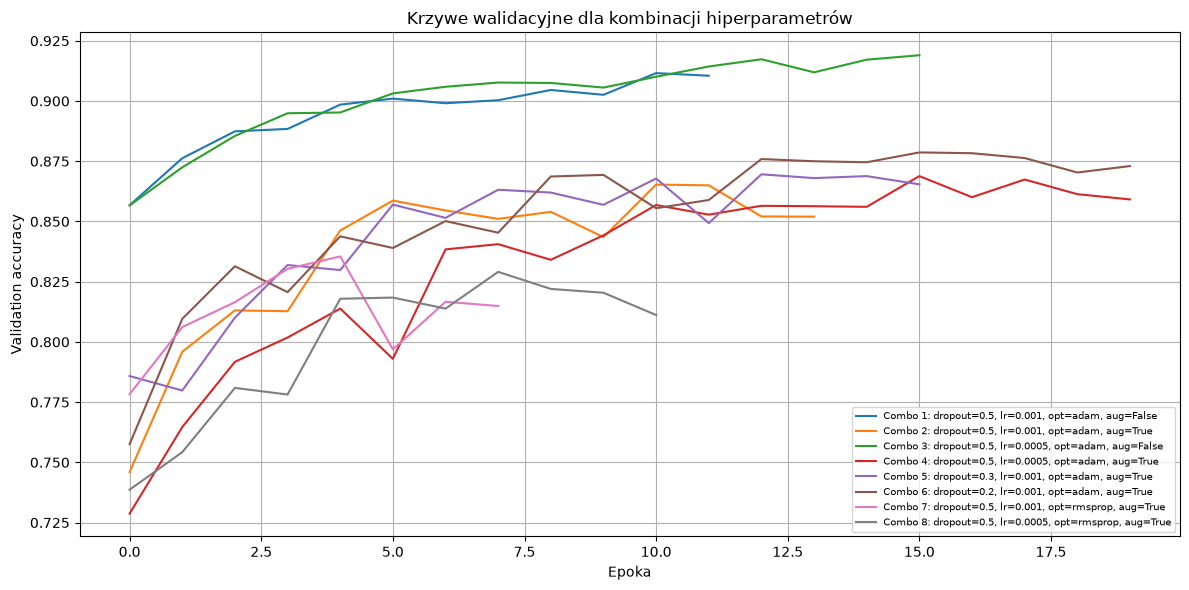

In [142]:
plt.figure(figsize=(12, 6))

for model_name, history in combo_histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=model_name
    )

plt.title("Krzywe walidacyjne dla kombinacji hiperparametrów")
plt.xlabel("Epoka")
plt.ylabel("Validation accuracy")
plt.legend(fontsize=7)
plt.grid(True)
plt.tight_layout()
plt.show()

# WNIOSKI - KOMBINACJE

Najlepsze rezultaty osiągnął model Combo 3 (dropout=0.5, learning rate=0.0005, optimizer=Adam, bez augmentacji), który uzyskał około 91,9% dokładności walidacyjnej.
Model ten przewyższył wszystkie pozostałe testowane konfiguracje, łącząc skuteczną regularyzację Dropout z odpowiednio małym krokiem uczenia.
Dzięki temu proces treningu był stabilny, a model osiągnął bardzo dobrą zdolność generalizacji.

Porównanie modeli z augmentacją i bez augmentacji pokazało, że we wszystkich testowanych kombinacjach wykorzystanie augmentacji prowadziło do obniżenia dokładności walidacyjnej.

Najlepsze modele z augmentacją osiągały około 87–88% accuracy, podczas gdy najlepsze modele bez augmentacji przekraczały 91%.
Potwierdza to wcześniejsze obserwacje, że dla niewielkich obrazów Fashion-MNIST augmentacja nie przynosiła korzyści.

Porównanie optymalizatorów potwierdziło przewagę algorytmu Adam. Modele wykorzystujące RMSprop osiągały zauważalnie słabsze wyniki, szczególnie w połączeniu z augmentacją danych.
Najgorsze rezultaty uzyskano dla konfiguracji wykorzystujących RMSprop oraz augmentację jednocześnie.

Wpływ współczynnika uczenia był również istotny. Zmniejszenie learning rate z 0.001 do 0.0005 pozwoliło uzyskać najwyższy wynik walidacyjny wśród wszystkich testowanych konfiguracji. Mniejszy krok aktualizacji wag poprawił stabilność uczenia i umożliwił dokładniejsze znalezienie minimum funkcji kosztu.

Uzyskane wyniki pokazują, że największy wpływ na poprawę jakości modelu miały odpowiednio dobrane wartości Dropout, Learning Rate oraz wybór optymalizatora Adam. Zastosowanie augmentacji danych nie poprawiło wyników i nie zostało uwzględnione w końcowej konfiguracji modelu.

## Wybór najlepszej kombinacji

In [143]:
# Pobieramy najlepszą kombinację z pierwszego wiersza posortowanej tabeli.

best_combo_name = combo_results_df.iloc[0]["Model"]
best_combo_model = combo_models[best_combo_name]

print("Najlepsza kombinacja hiperparametrów:")
print(best_combo_name)

print(
    f"Best validation accuracy: "
    f"{combo_results_df.iloc[0]['Best val_accuracy']:.4f}"
)

print(
    f"Best validation loss: "
    f"{combo_results_df.iloc[0]['Best val_loss']:.4f}"
)

Najlepsza kombinacja hiperparametrów:
Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False
Best validation accuracy: 0.9190
Best validation loss: 0.2416


# WNIOSKI - NAJLEPSZA KOMBINACJA

Najlepszą konfiguracją okazał się model Combo 3:
Dropout = 0.5,
Learning Rate = 0.0005,
Optimizer = Adam,
bez augmentacji danych.

Model ten osiągnął najwyższą dokładność walidacyjną (~91,9%) i został wybrany do dalszej ewaluacji na zbiorze testowym.
Na podstawie wyników można przypuszczać, że dodanie BatchNormalization do najlepszej konfiguracji Combo 3 mogłoby potencjalnie poprawić stabilność treningu i nieznacznie zwiększyć accuracy. Jednak ponieważ model Combo 3 już osiągnął najwyższy wynik walidacyjny, a różnica względem modelu z BatchNormalization była niewielka, w tym przypadku zysk również byłby nieznaczny lub żaden.

# ZBIORCZE WYNIKI DLA WSZYSTKICH MODELI

In [144]:
# Tworzymy DataFrame ze wszystkich wyników.

results_df = pd.DataFrame(results)

# Sortujemy modele od najlepszego do najgorszego.
results_df = results_df.sort_values(
    by="Best val_accuracy",
    ascending=False
)

# Resetujemy indeks.
results_df = results_df.reset_index(drop=True)

# Dodajemy ranking.
results_df.insert(
    0,
    "Ranking",
    range(1, len(results_df) + 1)
)

pd.set_option("display.max_colwidth", None)
results_df

,Ranking,Model,Best val_accuracy,Best val_loss,Liczba epok
0,1,"Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False",0.919000,0.241577,16
1,2,CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION,0.917333,0.275318,11
2,3,CNN Dropout 0.5,0.915583,0.252870,13
3,4,"Combo 1: dropout=0.5, lr=0.001, opt=adam, aug=False",0.911583,0.268443,12
4,5,CNN + Dropout,0.909333,0.257221,9
5,6,CNN optimizer adam,0.909083,0.261031,9
6,7,CNN LR 0.0005,0.908833,0.256903,10
7,8,CNN Dropout 0.3,0.908333,0.262061,9
8,9,CNN LR 0.001,0.908250,0.256904,8
9,10,CNN Dropout 0.2,0.908167,0.266176,9


# Podsumowanie eksperymentów

W ramach projektu porównano 25 modeli obejmujących różne architektury sieci neuronowych oraz konfiguracje hiperparametrów. Analizie poddano modele typu Baseline, MLP, CNN, a także warianty wykorzystujące Dropout, BatchNormalization, augmentację danych oraz różne wartości learning rate i optymalizatory.

## Wpływ architektury modelu

Najprostszym modelem był Baseline, który osiągnął około 85,9% dokładności walidacyjnej. Dodanie warstwy ukrytej w modelu MLP pozwoliło zwiększyć skuteczność do około 88,6%.
Pogłębienie architektury MLP nie przyniosło dalszej poprawy wyników, ponieważ model MLP Deep osiągnął nieco niższą dokładność niż MLP 128.
Największy wzrost jakości uzyskano po zastosowaniu sieci konwolucyjnej CNN. Model ten osiągnął około 90,4% dokładności walidacyjnej, potwierdzając przewagę warstw konwolucyjnych w zadaniach klasyfikacji obrazów.

## Wpływ regularyzacji

Zastosowanie Dropoutu poprawiło zdolność generalizacji modelu. Najlepsze wyniki spośród testowanych wartości uzyskano dla Dropout = 0.5, który osiągnął około 91,6% dokładności walidacyjnej.
Dodatkowe zastosowanie BatchNormalization pozwoliło jeszcze bardziej zwiększyć skuteczność klasyfikacji do około 91,7%. Oznacza to, że połączenie obu technik korzystnie wpłynęło na proces uczenia i ograniczenie przeuczenia modelu.

## Wpływ learning rate

Eksperymenty pokazały, że wartość współczynnika uczenia ma istotny wpływ na jakość modelu.
Zbyt duża wartość learning rate = 0.01 prowadziła do wyraźnie gorszych wyników (około 87,3% accuracy). Z kolei bardzo mała wartość 0.0001 zapewniała stabilny trening, ale wymagała większej liczby epok.
Najlepsze rezultaty uzyskano dla wartości 0.001 oraz 0.0005, przy czym learning rate = 0.0005 okazał się nieznacznie korzystniejszy w końcowych eksperymentach.

## Wpływ optymalizatora

Najlepszym optymalizatorem okazał się Adam, który zapewnił najwyższą dokładność oraz najszybszą zbieżność procesu uczenia.
RMSprop osiągał nieco słabsze wyniki, natomiast SGD trenował się wyraźnie wolniej i nie osiągnął skuteczności porównywalnej z Adamem.

## Wpływ augmentacji danych

W przeciwieństwie do oczekiwań augmentacja danych nie poprawiła jakości klasyfikacji. Wszystkie modele wykorzystujące augmentację osiągały wyniki wyraźnie słabsze od odpowiadających im wariantów bez augmentacji.
Prawdopodobną przyczyną jest niewielki rozmiar obrazów Fashion-MNIST (28×28 pikseli), przez co nawet niewielkie transformacje mogły utrudniać rozpoznawanie obiektów.


Przeprowadzone eksperymenty potwierdziły, że największy wpływ na skuteczność klasyfikacji miało zastosowanie sieci konwolucyjnej oraz odpowiednio dobranej regularyzacji. Najlepsze rezultaty uzyskano dzięki połączeniu architektury CNN z Dropout = 0.5, optymalizatorem Adam oraz odpowiednio dobranym współczynnikiem uczenia. Augmentacja danych nie przyniosła poprawy wyników, natomiast BatchNormalization okazało się skuteczną metodą zwiększającą jakość modelu i stabilność treningu.

# WYBÓR NAJLEPSZEGO MODELU

In [145]:
# Na podstawie validation accuracy wybieramy model,
# który osiągnął najwyższą skuteczność na zbiorze walidacyjnym.
best_model_name = results_df.iloc[0]["Model"]

print("Najlepszy model:")
print(best_model_name)

Najlepszy model:
Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False


# WNIOSKI NAJLEPSZY MODEL ZE WSZYSTKICH EKSPERYMENTÓW

Najwyższą dokładność walidacyjną osiągnął model Combo 3:

Dropout = 0.5
Learning Rate = 0.0005
Optimizer = Adam
bez augmentacji danych

który uzyskał około 91,9% accuracy oraz najniższą wartość funkcji straty spośród wszystkich testowanych konfiguracji.

3 pierwsze modele zostały wybrane do dalszej ewaluacji na zbiorze testowym.

# EWALUACJA NA ZBIORZE TESTOWYM

In [146]:
# Tworzymy słownik wszystkich wytrenowanych modeli.

all_models = {
    "Baseline": baseline_model,
    "MLP 128": mlp_128,
    "MLP Deep": mlp_deep,
    "CNN": cnn_model,
    "CNN + Dropout": cnn_dropout,
    "CNN + Augmentation": cnn_augmentation,
    "CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION": cnn_batchnorm
}

# Modele z tuningu Dropout.
for dropout_rate, model in dropout_models.items():
    all_models[f"CNN Dropout {dropout_rate}"] = model

# Modele z tuningu learning rate.
for lr, model in lr_models.items():
    all_models[f"CNN LR {lr}"] = model

# Modele z tuningu optymalizatora.
for optimizer_name, model in optimizer_models.items():
    all_models[f"CNN optimizer {optimizer_name}"] = model

# Modele z końcowych kombinacji hiperparametrów.
for model_name, model in combo_models.items():
    all_models[model_name] = model

In [147]:
# Pobieramy 3 najlepsze modele według validation accuracy.

top3 = results_df.head(3)

pd.set_option("display.max_colwidth", None)
top3

,Ranking,Model,Best val_accuracy,Best val_loss,Liczba epok
0,1,"Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False",0.919000,0.241577,16
1,2,CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION,0.917333,0.275318,11
2,3,CNN Dropout 0.5,0.915583,0.252870,13


In [148]:
# Lista do przechowywania wyników testowych.

test_results = []

# Przechodzimy po trzech najlepszych modelach.
for _, row in top3.iterrows():

    model_name = row["Model"]

    print(f"Testowanie modelu: {model_name}")

    # Pobieramy model ze słownika.
    model = all_models[model_name]

    # Obliczamy wynik na zbiorze testowym.
    test_loss, test_accuracy = model.evaluate(
        X_test_cnn,
        y_test,
        verbose=0
    )

    # Zapisujemy wyniki.
    test_results.append({
        "Model": model_name,
        "Validation accuracy": row["Best val_accuracy"],
        "Test accuracy": test_accuracy,
        "Test loss": test_loss
    })

Testowanie modelu: Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False
Testowanie modelu: CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION
Testowanie modelu: CNN Dropout 0.5


# TABELA WYNIKÓW EWALUACJI NA ZBIORZE TESTOWYM

In [149]:
test_results_df = pd.DataFrame(test_results)

test_results_df = test_results_df.sort_values(
    by="Test accuracy",
    ascending=False
)

pd.set_option("display.max_colwidth", None)
test_results_df

,Model,Validation accuracy,Test accuracy,Test loss
1,CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION,0.917333,0.9119,0.301042
0,"Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False",0.919000,0.9089,0.261095
2,CNN Dropout 0.5,0.915583,0.9054,0.267730


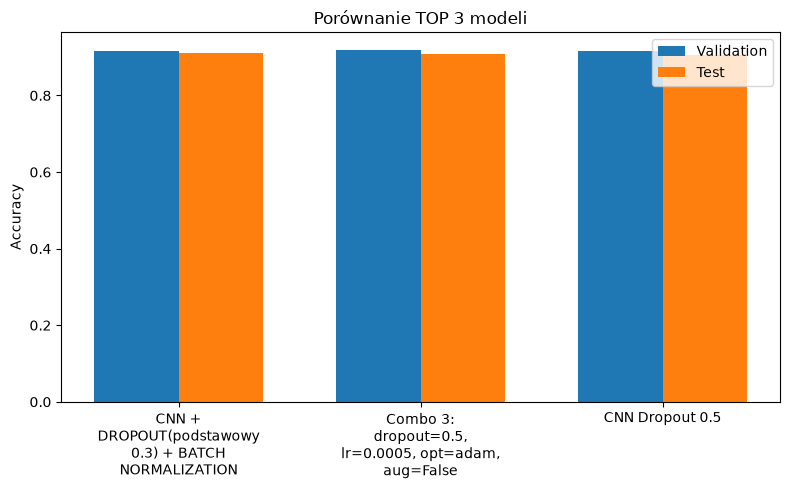

In [150]:
import textwrap
plt.figure(figsize=(8, 5))

x = np.arange(len(test_results_df))

width = 0.35

plt.bar(
    x - width/2,
    test_results_df["Validation accuracy"],
    width,
    label="Validation"
)

plt.bar(
    x + width/2,
    test_results_df["Test accuracy"],
    width,
    label="Test"
)

#zawijanie tekstu podpisów
wrapped_labels = [
    "\n".join(textwrap.wrap(label, width=20))
    for label in test_results_df["Model"]
]

plt.xticks(
    x,
    wrapped_labels
)

plt.ylabel("Accuracy")
plt.title("Porównanie TOP 3 modeli")

plt.legend()

plt.tight_layout()
plt.show()

# WNIOSKI - EWALUACJA NA ZBIORZE TESTOWYM

Po zakończeniu procesu strojenia hiperparametrów przeprowadzono końcową ewaluację trzech najlepszych modeli na niezależnym zbiorze testowym.
Wszystkie analizowane modele osiągnęły bardzo zbliżone wyniki, przekraczając 90% dokładności testowej. Potwierdza to wysoką jakość opracowanych architektur oraz dobrą zdolność generalizacji na nowych danych.
Najwyższą dokładność testową uzyskał model CNN + BatchNormalization + Dropout 0.3, osiągając około 91,2% accuracy. Wynik ten był nieznacznie lepszy od najlepszego modelu wybranego na podstawie walidacji.
Model Combo 3, który osiągnął najwyższą dokładność walidacyjną (91,9%), uzyskał około 90,9% accuracy na zbiorze testowym. Oznacza to, że przewaga obserwowana podczas walidacji nie przełożyła się w pełni na nowe dane.
Model CNN Dropout 0.5 osiągnął około 90,5% accuracy, uzyskując wynik jedynie nieznacznie słabszy od dwóch pozostałych modeli.

Warto zauważyć, że różnice pomiędzy wszystkimi trzema modelami były bardzo niewielkie i nie przekraczały jednego punktu procentowego. Oznacza to, że wszystkie należały do tej samej klasy jakościowej i zapewniały podobną skuteczność klasyfikacji.

Porównanie wyników walidacyjnych i testowych pokazuje, że ranking uzyskany podczas walidacji nie zawsze idealnie odzwierciedla rzeczywistą skuteczność modelu na nowych danych.
Mimo że model Combo 3 był najlepszy na zbiorze walidacyjnym, ostatecznie najwyższą dokładność testową osiągnął model wykorzystujący BatchNormalization. Może to sugerować, że normalizacja aktywacji poprawiła zdolność modelu do generalizacji, mimo nieco słabszego wyniku walidacyjnego.

# WYBÓR NAJLEPSZEGO MODELU

In [151]:
# Wybieramy model, który uzyskał najwyższe accuracy na zbiorze testowym.

final_model_name = test_results_df.iloc[0]["Model"]

final_model = all_models[final_model_name]

print("Finalny model:")
print(final_model_name)

Finalny model:
CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION


# WNIOSKI - NAJLEPSZY MODEL PO EWALUACJI TESTOWEJ

Najlepszym modelem w końcowej ewaluacji okazał się CNN + BatchNormalization + Dropout 0.3, który osiągnął najwyższą dokładność testową wynoszącą około 91,2%.

Jednocześnie bardzo niewielkie różnice pomiędzy wynikami TOP 3 modeli wskazują, że kluczowe znaczenie miało zastosowanie architektury CNN oraz odpowiedniej regularyzacji, natomiast dokładny dobór hiperparametrów wpływał już jedynie na niewielkie różnice w skuteczności klasyfikacji.

## Predykcje finalnego modelu

In [152]:
# Model zwraca prawdopodobieństwa dla każdej z 10 klas.
# Za ostateczną predykcję przyjmujemy klasę z najwyższym prawdopodobieństwem.

y_pred_probs = final_model.predict(X_test_cnn)

y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


## Raport klasyfikacji

In [153]:

# Raport klasyfikacji pokazuje wyniki osobno dla każdej klasy:
#
# Precision (precyzja)
# Spośród wszystkich przykładów przypisanych przez model do danej klasy,
# jaki procent rzeczywiście należał do tej klasy.
#
# Recall (czułość)
# Spośród wszystkich rzeczywistych przykładów danej klasy,
# jaki procent został poprawnie wykryty przez model.
#
# F1-score
# Średnia harmoniczna precision i recall.
# Jest dobrą miarą ogólnej jakości klasyfikacji dla danej klasy.
#
# Support
# Liczba przykładów danej klasy występujących w zbiorze testowym.

from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Klasy
print("WYNIKI DLA POSZCZEGÓLNYCH KLAS\n")
display(report_df.iloc[:10])

print("\nWYNIKI DLA CAŁEGO MODELU\n")

# accuracy + avg
display(report_df.iloc[10:])

WYNIKI DLA POSZCZEGÓLNYCH KLAS



,precision,recall,f1-score,support
T-shirt/top,0.891099,0.851,0.870588,1000.0
Trouser,0.997936,0.967,0.982224,1000.0
Pullover,0.878447,0.860,0.869126,1000.0
Dress,0.882353,0.930,0.905550,1000.0
Coat,0.849566,0.881,0.864998,1000.0
Sandal,0.987792,0.971,0.979324,1000.0
Shirt,0.739645,0.750,0.744786,1000.0
Sneaker,0.941459,0.981,0.960823,1000.0
Bag,0.982776,0.970,0.976346,1000.0
Ankle boot,0.977551,0.958,0.967677,1000.0



WYNIKI DLA CAŁEGO MODELU



,precision,recall,f1-score,support
accuracy,0.911900,0.9119,0.911900,0.9119
macro avg,0.912863,0.9119,0.912144,10000.0000
weighted avg,0.912863,0.9119,0.912144,10000.0000


# WNIOSKI - KLASYFIKACJA

Raport klasyfikacji pokazuje, że model osiągnął około 91,2% dokładności na zbiorze testowym. Wartości precision, recall i F1-score dla większości klas przekraczały 0,85, co świadczy o wysokiej jakości klasyfikacji.

Najlepiej rozpoznawanymi klasami były Trouser, Sandal, Sneaker, Bag oraz Ankle boot. Dla tych kategorii uzyskano wartości F1-score przekraczające 0,96. Oznacza to, że model bardzo skutecznie identyfikował obiekty o charakterystycznym kształcie i wyglądzie.

Dobre wyniki uzyskano również dla klasy Dress, która osiągnęła F1-score na poziomie około 0,91. Wskazuje to na wysoką skuteczność rozpoznawania tej kategorii odzieży.

Największe trudności model miał z klasami Shirt, T-shirt/top, Pullover oraz Coat. Szczególnie klasa Shirt osiągnęła najniższy wynik F1-score wynoszący około 0,74. Jest to prawdopodobnie związane z dużym podobieństwem wizualnym tych kategorii ubrań.

Wysokie wartości precision i recall dla większości klas pokazują, że model zachowuje równowagę pomiędzy poprawnym wykrywaniem obiektów a ograniczaniem liczby błędnych klasyfikacji.

## Macierz pomyłek

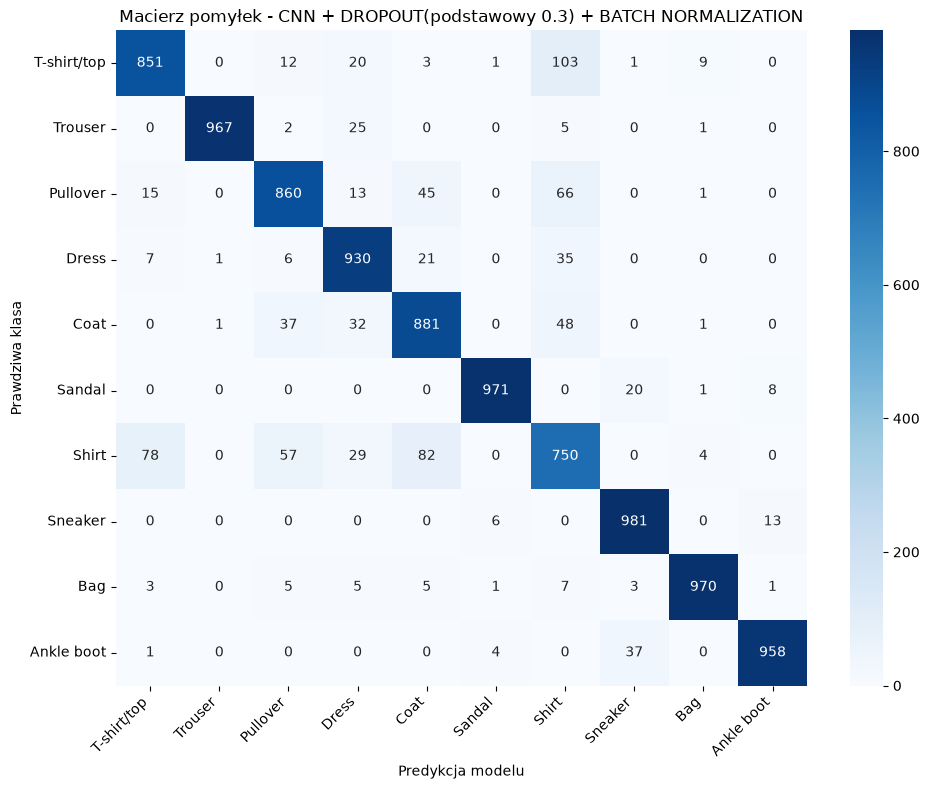

In [154]:
# Macierz pomyłek pokazuje, które klasy model rozpoznaje poprawnie,
# a które najczęściej myli ze sobą.

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(f"Macierz pomyłek - {final_model_name}")
plt.xlabel("Predykcja modelu")
plt.ylabel("Prawdziwa klasa")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# WNIOSKI - MAPA POMYŁEK

Macierz pomyłek pokazuje, że większość obserwacji została sklasyfikowana poprawnie, co potwierdzają wysokie wartości znajdujące się na głównej przekątnej macierzy. Największą liczbę poprawnych klasyfikacji uzyskano dla klas Sneaker (981), Bag (970), Sandal (971), Trouser (967) oraz Ankle boot (958).
Wyniki te potwierdzają, że model bardzo dobrze rozpoznaje obiekty posiadające charakterystyczne cechy wizualne, szczególnie obuwie, torby oraz spodnie.

Najwyższą skuteczność model osiągnął dla klas:

- Sneaker – 981 poprawnych klasyfikacji,
- Sandal – 971 poprawnych klasyfikacji,
- Bag – 970 poprawnych klasyfikacji,
- Trouser – 967 poprawnych klasyfikacji,
- Ankle boot – 958 poprawnych klasyfikacji.

Kategorie te różnią się od pozostałych klas wyraźnym kształtem, dlatego model rzadko je mylił z innymi obiektami.

Analiza wartości poza główną przekątną pokazuje, że model najczęściej mylił:

- T-shirt/top z Shirt (103 przypadki),
- Shirt z Coat (82 przypadki),
- Shirt z T-shirt/top (78 przypadków),
- Pullover z Shirt (66 przypadków),
- Shirt z Pullover (57 przypadków),
- Coat z Shirt (48 przypadków),
- Pullover z Coat (45 przypadków).

Błędy te dotyczą głównie podobnych kategorii odzieży, które nawet dla człowieka mogą być trudne do rozróżnienia na małych, czarno-białych obrazach Fashion-MNIST.

Macierz pomyłek potwierdza wnioski z raportu klasyfikacji. Model osiąga bardzo wysoką skuteczność dla klas posiadających unikalne cechy wizualne, natomiast największe problemy występują dla podobnych typów ubrań górnych.

Warto zauważyć, że błędy nie są rozłożone losowo. Większość pomyłek występuje pomiędzy klasami, które są semantycznie i wizualnie podobne, co wskazuje, że model nauczył się poprawnych zależności i nie popełnia przypadkowych błędów.

## METRYKI KAŻDEJ KLASY

In [155]:
# Zamieniamy classification_report na DataFrame,
# żeby łatwiej analizować wyniki dla pojedynczych klas.
# support oznacza ilość przykładów w klasie

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
T-shirt/top,0.891099,0.8510,0.870588,1000.0000
Trouser,0.997936,0.9670,0.982224,1000.0000
Pullover,0.878447,0.8600,0.869126,1000.0000
Dress,0.882353,0.9300,0.905550,1000.0000
Coat,0.849566,0.8810,0.864998,1000.0000
Sandal,0.987792,0.9710,0.979324,1000.0000
Shirt,0.739645,0.7500,0.744786,1000.0000
Sneaker,0.941459,0.9810,0.960823,1000.0000
Bag,0.982776,0.9700,0.976346,1000.0000
Ankle boot,0.977551,0.9580,0.967677,1000.0000


# WNIOSKI - METRYKI

Analiza wyników dla poszczególnych klas pokazuje, że model osiąga bardzo wysoką skuteczność rozpoznawania większości kategorii obiektów.

Najlepiej rozpoznawanymi klasami były:
- Sneaker (recall = 98,1%),
- Sandal (recall = 97,1%),
- Bag (recall = 97,0%),
- Trouser (recall = 96,7%),
- Ankle boot (recall = 95,8%).

Oznacza to, że dla tych kategorii model poprawnie identyfikował ponad 95% wszystkich przykładów występujących w zbiorze testowym.

Dobrą skuteczność uzyskano również dla klasy Dress (93,0%) oraz Coat (88,1%).

Największe trudności wystąpiły dla klas:
- Shirt (75,0%),
- T-shirt/top (85,1%),
- Pullover (86,0%).

Szczególnie klasa Shirt była najtrudniejsza do rozpoznania. Jedynie 75% rzeczywistych przykładów tej klasy zostało sklasyfikowanych poprawnie, natomiast pozostałe obrazy były najczęściej mylone z T-shirt/top, Pullover oraz Coat.

Uzyskane wyniki wskazują, że model znacznie lepiej radzi sobie z klasami posiadającymi charakterystyczne cechy wizualne, takimi jak obuwie, torby czy spodnie, niż z podobnymi do siebie elementami odzieży górnej.

## Wykres F1-score dla klas

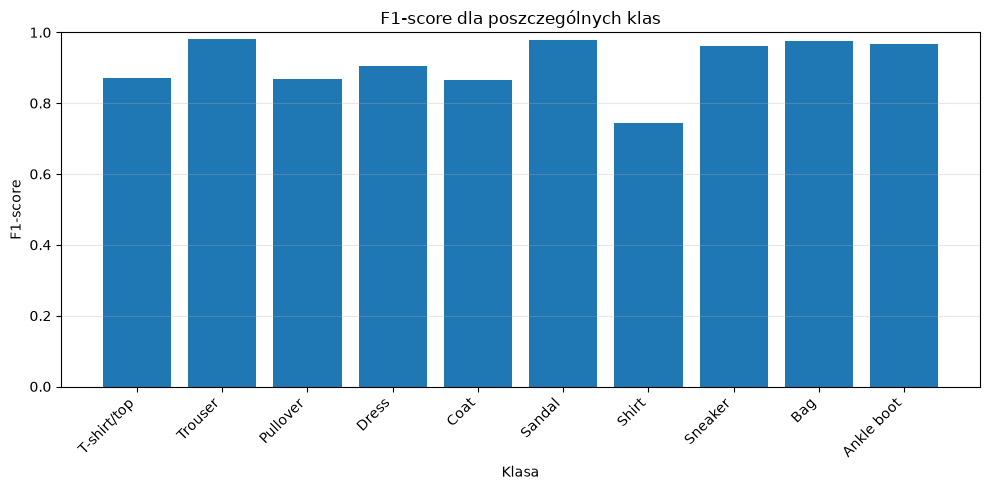

In [156]:
# F1-score łączy precision i recall.
# Dzięki temu dobrze pokazuje, z którymi klasami model radzi sobie najlepiej i najgorzej.

classes_report_df = report_df.iloc[:10].copy()

plt.figure(figsize=(10, 5))

plt.bar(
    classes_report_df.index,
    classes_report_df["f1-score"]
)

plt.title("F1-score dla poszczególnych klas")
plt.xlabel("Klasa")
plt.ylabel("F1-score")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# WNIOSKI F1-SCORE

Wykres F1-score pokazuje jakość klasyfikacji dla każdej klasy z uwzględnieniem zarówno precision, jak i recall. Dzięki temu F1-score jest jedną z najbardziej kompleksowych miar oceny modelu dla poszczególnych kategorii.

Dla większości klas uzyskano bardzo wysokie wartości F1-score, przekraczające 0,85, co świadczy o dobrej skuteczności modelu w rozpoznawaniu różnych typów odzieży i obuwia.

Najwyższe wartości F1-score uzyskano dla klas:

- Trouser – 0,982,
- Sandal – 0,979,
- Bag – 0,976,
- Ankle boot – 0,968,
- Sneaker – 0,961.

Oznacza to, że model bardzo skutecznie identyfikował te kategorie, jednocześnie osiągając wysoką precyzję i czułość. Są to klasy posiadające charakterystyczne cechy wizualne, dzięki czemu rzadko były mylone z innymi obiektami.

Rozkład wartości F1-score jest zgodny z wcześniejszą analizą raportu klasyfikacji oraz macierzy pomyłek. Model osiąga najwyższą skuteczność dla klas posiadających wyraźne i unikalne cechy wizualne, natomiast największe problemy występują dla podobnych kategorii ubrań.

Pomimo tych trudności nawet najsłabsza klasa osiągnęła wynik F1-score przekraczający 0,74, co nadal świadczy o stosunkowo dobrej jakości klasyfikacji.

Analiza F1-score potwierdza wysoką skuteczność wytrenowanego modelu. Większość klas osiągnęła wartości przekraczające 0,9, a najlepsze kategorie zbliżały się do wyniku idealnego. Największe trudności dotyczyły klas odzieży górnej, które charakteryzują się dużym podobieństwem wizualnym, jednak nawet w tych przypadkach model zachował zadowalającą skuteczność klasyfikacji.

***Wartości F1-score potwierdzają, że model najskuteczniej rozpoznaje klasy o charakterystycznym wyglądzie (Trouser, Sandal, Bag), natomiast największe trudności występują dla podobnych do siebie elementów odzieży górnej (Shirt, T-shirt/top, Pullover i Coat).

## Analiza błędnych klasyfikacji

In [157]:
# Szukamy indeksów obrazów, które zostały sklasyfikowane błędnie.

wrong_indices = np.where(y_pred != y_test)[0]

print("Liczba błędnych klasyfikacji:", len(wrong_indices))
print("Liczba wszystkich przykładów testowych:", len(y_test))
print(f"Odsetek błędów: {len(wrong_indices) / len(y_test):.4f}")

Liczba błędnych klasyfikacji: 881
Liczba wszystkich przykładów testowych: 10000
Odsetek błędów: 0.0881


## Przykładowe błędne klasyfikacje

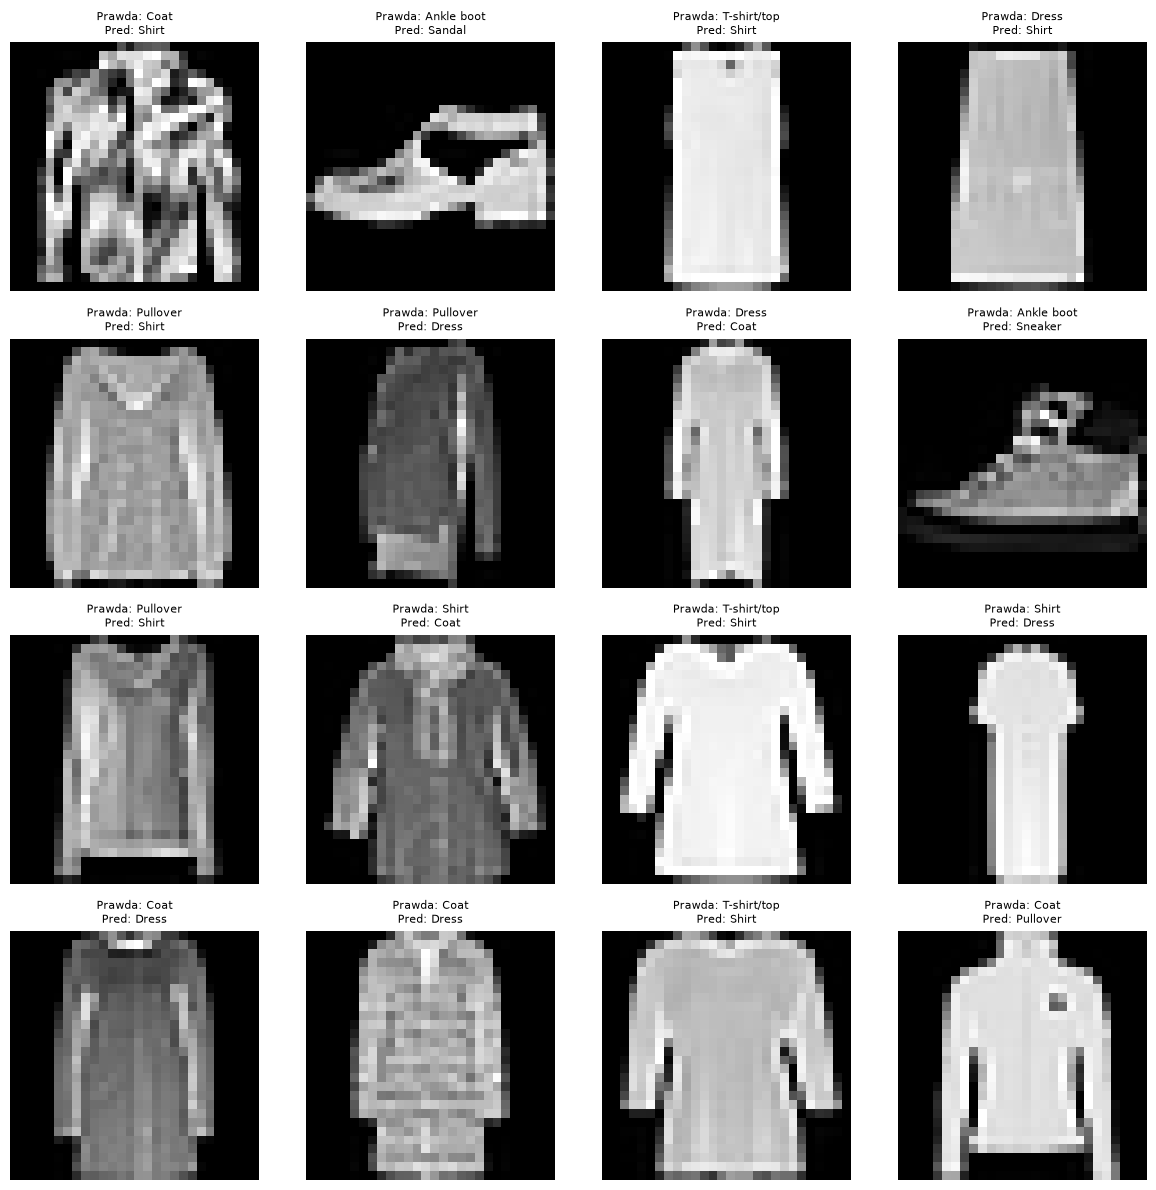

In [158]:
# Przykładowe błędy modelu.
# Pozwala to zobaczyć, czy pomyłki są zrozumiałe wizualnie.

plt.figure(figsize=(12, 12))

for i, idx in enumerate(wrong_indices[:16]):

    plt.subplot(4, 4, i + 1)

    plt.imshow(X_test[idx], cmap="gray")

    true_label = class_names[y_test[idx]]
    predicted_label = class_names[y_pred[idx]]

    plt.title(
        f"Prawda: {true_label}\nPred: {predicted_label}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Najczęściej mylone klasy

In [159]:

# Tworzymy kopię macierzy pomyłek.
# Na przekątnej znajdują się poprawne klasyfikacje,
# dlatego ustawiamy je na 0, aby analizować tylko błędy modelu.

cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)


# Lista, w której zapiszemy wszystkie błędne klasyfikacje.
mistakes = []


# Przechodzimy po wszystkich parach:
# prawdziwa klasa to klasa przewidziana przez model.
for true_class in range(len(class_names)):

    for predicted_class in range(len(class_names)):

        count = cm_errors[true_class, predicted_class]

        # Zapisujemy tylko te przypadki, w których wystąpiła pomyłka.
        if count > 0:

            mistakes.append({
                "Prawdziwa klasa": class_names[true_class],
                "Predykcja modelu": class_names[predicted_class],
                "Liczba pomyłek": count
            })


# Zamieniamy listę pomyłek na DataFrame.
mistakes_df = pd.DataFrame(mistakes)


# Sortujemy pomyłki od najczęstszych do najrzadszych.
mistakes_df = mistakes_df.sort_values(
    by="Liczba pomyłek",
    ascending=False
)


# Resetujemy indeks, żeby tabela była uporządkowana od 0.
mistakes_df = mistakes_df.reset_index(drop=True)


# Wybieramy 10 najczęstszych pomyłek.
top_mistakes = mistakes_df.head(10).copy()


# Ustawiamy indeks od 1, żeby pełnił funkcję rankingu.
top_mistakes.index = range(1, len(top_mistakes) + 1)

top_mistakes

,Prawdziwa klasa,Predykcja modelu,Liczba pomyłek
1,T-shirt/top,Shirt,103
2,Shirt,Coat,82
3,Shirt,T-shirt/top,78
4,Pullover,Shirt,66
5,Shirt,Pullover,57
6,Coat,Shirt,48
7,Pullover,Coat,45
8,Coat,Pullover,37
9,Ankle boot,Sneaker,37
10,Dress,Shirt,35


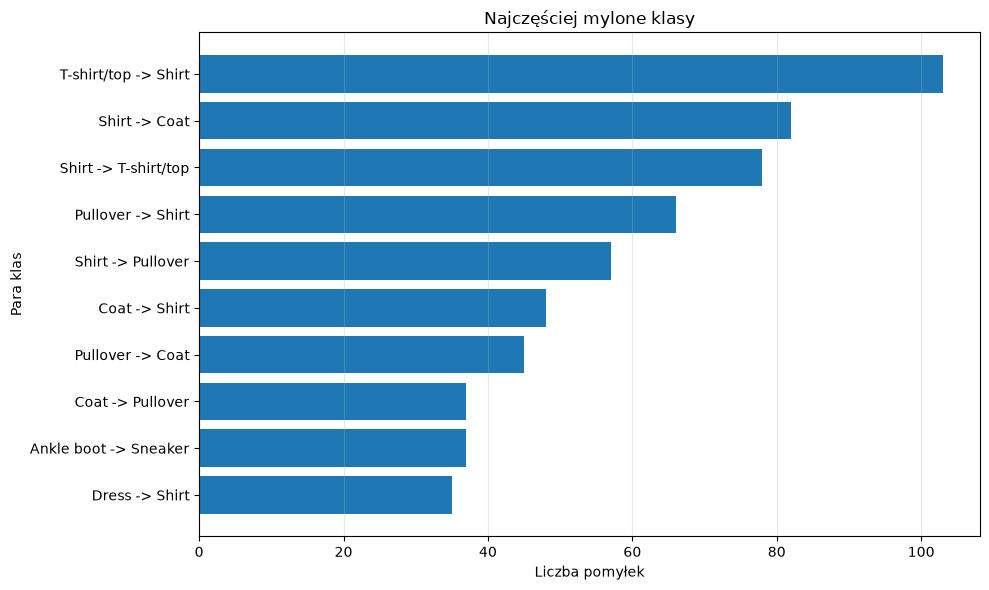

In [160]:
# Tworzymy etykietę pokazującą kierunek pomyłki:
# prawdziwa klasa to predykcja modelu.

top_mistakes_plot = top_mistakes.copy()

top_mistakes_plot["Para klas"] = (
    top_mistakes_plot["Prawdziwa klasa"]
    + " -> "
    + top_mistakes_plot["Predykcja modelu"]
)


plt.figure(figsize=(10, 6))

plt.barh(
    top_mistakes_plot["Para klas"],
    top_mistakes_plot["Liczba pomyłek"]
)

plt.title("Najczęściej mylone klasy")
plt.xlabel("Liczba pomyłek")
plt.ylabel("Para klas")

# Najczęstsza pomyłka na górze.
plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# Ranking najczęściej mylonych klas pozwala określić,
# które kategorie ubrań są najbardziej podobne z punktu widzenia modelu.
#
# Wysoka liczba pomyłek pomiędzy dwiema klasami oznacza,
# że obrazy tych kategorii mają podobne cechy wizualne
# i są trudniejsze do rozróżnienia.
#
# Dla zbioru Fashion-MNIST najczęściej obserwuje się pomyłki
# pomiędzy klasami Shirt, T-shirt/top, Coat oraz Pullover,
# ponieważ ich kształty i kontury są do siebie zbliżone.